# From an RMS-origin reservoir model to OPM Flow, ERT, and NeqSim

**A fully executed NeqSim-Colab reservoir example using the public Reek model**

This notebook reads a real exported corner-point model whose public provenance identifies an
RMS project, audits every input by SHA-256, demonstrates 2 × 2 × 4 blocking and property
spreading, generates a complete OPM Flow black-oil case, runs the simulator, reads restart
states, runs a four-realization ERT ensemble, and transfers a selected result to a NeqSim
surface-process model.

Open in Colab:
https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/rms_to_opm_flow_agent_ert.ipynb

The stored outputs are evidence from a clean top-to-bottom run. Re-running will download the
same immutable public inputs and will build the current NeqSim Java master, recording its exact
commit and JAR digest.

## What this notebook proves

By the end, the notebook has produced and checked:

1. An immutable inventory of the public Reek ROFF files, including geometry and all properties.
2. A geological grid of 80 × 128 × 56 cells and a simulation grid of 40 × 64 × 14 cells.
3. Explicit 2 × 2 × 4 blocking, pore-volume-weighted porosity, and volume-majority facies.
4. Property maps, cross-sections, histograms, a 3-D reservoir view, and well screening.
5. NeqSim SRK fluid characterization and Flow-compatible PVTO, PVDG, PVTW, and DENSITY data.
6. A complete OPM Flow corner-point deck and a real dynamic simulation with restart maps.
7. A real ERT ensemble experiment in which porosity, permeability, and injection rate vary.
8. A NeqSim choke, separation, compression, cooling, and oil-letdown process driven by Flow rates.
9. A machine-readable job contract and tool-call ledger for a future RMS automation agent.

**Important boundary.** RMS is commercial software and cannot be installed in a public Colab
runtime. The numerical data used here are genuine public ROFF exports from an RMS-origin Reek
model. The future-agent section shows how the same request is dispatched to a licensed,
allow-listed RMS worker. No proprietary project or license is copied into this notebook.

## End-to-end architecture and trust boundary

The public teaching path and the future licensed path share the same versioned handover contract.

| Stage | This executed notebook | Future production agent |
|---|---|---|
| RMS source | Public RMS-origin ROFF export | Licensed RMS worker |
| Grid/property API | XTGeo | RMS Python API plus XTGeo validation |
| Fluid model | NeqSim current Java master | Same |
| Dynamic model | OPM Flow 2026.04 | Same or approved simulator |
| Uncertainty | ERT 23.0.1 | ERT with governed storage/compute |
| Audit | Checksums, assertions, tool ledger | Signed job, identity, approvals, artifact registry |

In [1]:
import importlib.metadata
import os
from pathlib import Path
import re
import shutil
import subprocess
import sys

REQUIRED_PACKAGES = {
    "neqsim": "3.18.0",
    "opm": "2026.4",
    "xtgeo": "4.25.1",
    "ert": "23.0.1",
    "nbformat": "5.10.4",
}

installed = {}
for package_name in REQUIRED_PACKAGES:
    try:
        installed[package_name] = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        installed[package_name] = None

requirements = [
    f"{name}=={required}"
    for name, required in REQUIRED_PACKAGES.items()
    if installed[name] != required
]
if requirements:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *requirements],
        check=True,
        timeout=1200,
    )

FLOW_RUN_ENV = os.environ.copy()
FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE") or shutil.which("flow")
if FLOW_EXECUTABLE is None:
    os_release = Path("/etc/os-release").read_text(encoding="utf-8")
    if "Ubuntu" not in os_release:
        raise RuntimeError("OPM Flow binary installation requires an Ubuntu/Colab runtime.")
    privilege = [] if os.geteuid() == 0 else ["sudo"]
    commands = [
        privilege + ["apt-get", "update", "-qq"],
        privilege + [
            "apt-get", "install", "-y", "-qq", "--no-install-recommends",
            "software-properties-common", "mpi-default-bin",
        ],
        privilege + ["add-apt-repository", "-y", "ppa:opm/ppa"],
        privilege + ["apt-get", "update", "-qq"],
        privilege + [
            "apt-get", "install", "-y", "-qq", "--no-install-recommends",
            "libopm-simulators-bin",
        ],
    ]
    for command in commands:
        result = subprocess.run(command, capture_output=True, text=True, timeout=1200)
        if result.returncode != 0:
            raise RuntimeError(result.stdout[-2000:] + "\n" + result.stderr[-4000:])
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    raise RuntimeError("The OPM Flow executable was not found.")

flow_version_output = subprocess.run(
    [FLOW_EXECUTABLE, "--version"],
    check=True,
    capture_output=True,
    text=True,
    timeout=60,
)
print(flow_version_output.stdout.strip() or flow_version_output.stderr.strip())
print("Python packages installed:", REQUIRED_PACKAGES)

flow 2026.04
Python packages installed: {'neqsim': '3.18.0', 'opm': '2026.4', 'xtgeo': '4.25.1', 'ert': '23.0.1', 'nbformat': '5.10.4'}


## Reproducible current-master NeqSim runtime

The public PyPI NeqSim package supplies only the Python bridge. The Java runtime below is built
from the selected equinor/neqsim source ref. The resolved Git commit, JAR SHA-256, and loaded
class location are recorded before any thermodynamic calculation. Set NEQSIM_SOURCE_REF to use
another reviewed ref. Validation automation may provide NEQSIM_SOURCE_ROOT and
NEQSIM_SOURCE_JAR from an exact pre-built checkout.

In [2]:
import hashlib
import importlib.util
import jpype


def run_command(command, *, cwd=None, timeout=1800, environment=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        env=environment,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path(os.environ.get("RUNNER_TEMP", "/tmp")).resolve()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git", str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
                    cwd=neqsim_source, timeout=600)
        run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)

    maven_settings = build_root / "neqsim-maven-settings.xml"
    maven_settings.write_text(
        "<settings><mirrors><mirror><id>canonical-central</id>"
        "<mirrorOf>central</mirrorOf>"
        "<url>https://repo.maven.apache.org/maven2/</url>"
        "</mirror></mirrors></settings>",
        encoding="utf-8",
    )
    run_command(
        [
            "./mvnw", "-q", "-s", str(maven_settings), "-DskipTests",
            "-Dmaven.javadoc.skip=true", "package",
        ],
        cwd=neqsim_source,
        timeout=2400,
    )
    built_jars = [
        path for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    ]
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = max(built_jars, key=lambda path: path.stat().st_size)

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    neqsim_package = importlib.util.find_spec("neqsim")
    if neqsim_package is None or not neqsim_package.submodule_search_locations:
        raise ImportError("The public-PyPI neqsim bridge is not installed.")
    neqsim_python_root = Path(next(iter(neqsim_package.submodule_search_locations)))
    for runtime_jar in sorted((neqsim_python_root / "lib").glob("*.jar")):
        if runtime_jar.resolve() != neqsim_jar:
            jpype.addClassPath(str(runtime_jar))
    jpype.startJVM()

SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

print("NeqSim source ref:", NEQSIM_SOURCE_REF)
print("NeqSim resolved commit:", neqsim_commit)
print("NeqSim JAR SHA-256:", neqsim_jar_sha256)
print("Loaded class source:", class_source)

NeqSim source ref: master
NeqSim resolved commit: 1f7a01b06307d9d56451e43bb8d6023d28d14007
NeqSim JAR SHA-256: 39e1de9738baaef18726c5d7a3f9cccf3a8af29a8e39761f90d92b870b0a857a
Loaded class source: file:/home/runner/work/_temp/neqsim-java-master/target/neqsim-3.18.0.jar


In [3]:
from importlib.metadata import version
import json
import math
import platform
import textwrap
import time
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import xtgeo
from jpype import JClass
from neqsim import jneqsim
from neqsim.process.processTools import (
    clearProcess, compressor, cooler, mixer, runProcess, separator,
    separator3phase, stream, valve,
)
from neqsim.thermo import TPflash
from opm.io import Parser
from opm.io.ecl import EclFile, EGrid, ERst, ESmry

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)

RANDOM_SEED = 20260831
RESERVOIR_TEMPERATURE_C = 97.5
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
INITIAL_RESERVOIR_PRESSURE_BARA = 260.0
PRODUCER_BHP_LIMIT_BARA = 80.0
SECONDS_PER_DAY = 86400.0
DLE_PRESSURES_BARA = np.array([300.0, 250.0, 220.0, 200.0, 180.0, 150.0, 100.0, 50.0, 1.01325])
GAS_PVT_PRESSURES_BARA = np.array([1.01325, 25.0, 50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0, 275.0, 300.0])

OUTPUT_DIRECTORY = Path("rms_to_opm_outputs").resolve()
DATA_DIRECTORY = OUTPUT_DIRECTORY / "input"
ERT_DIRECTORY = OUTPUT_DIRECTORY / "ert"
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
DATA_DIRECTORY.mkdir(parents=True)
ERT_DIRECTORY.mkdir(parents=True)
FIGURE_PATHS = []

runtime_table = pd.DataFrame({
    "runtime": ["Python", "Java", "NeqSim Python bridge", "NeqSim Java", "XTGeo", "OPM Python", "OPM Flow", "ERT"],
    "version or identity": [
        platform.python_version(),
        subprocess.run(["java", "-version"], capture_output=True, text=True, check=True).stderr.splitlines()[0],
        version("neqsim"),
        neqsim_commit[:12],
        version("xtgeo"),
        version("opm"),
        (flow_version_output.stdout or flow_version_output.stderr).strip().splitlines()[0],
        version("ert"),
    ],
})
display(runtime_table)

,runtime,version or identity
0,Python,3.12.14
1,Java,"openjdk version ""17.0.20.1"" 2026-08-18"
2,NeqSim Python bridge,3.18.0
3,NeqSim Java,1f7a01b06307
4,XTGeo,4.25.1
5,OPM Python,2026.4
6,OPM Flow,flow 2026.04
7,ERT,23.0.1


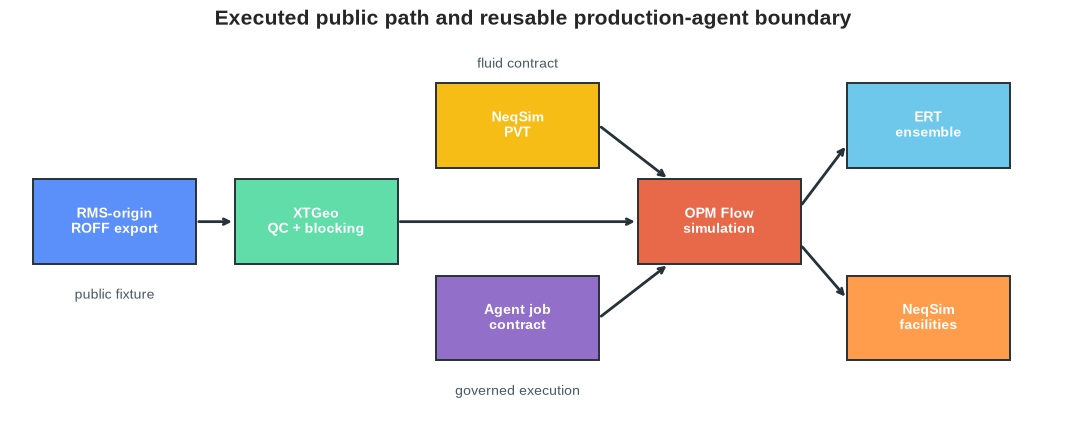

In [4]:
architecture_figure, axis = plt.subplots(figsize=(13.5, 5.0))
axis.set_xlim(0, 13.5)
axis.set_ylim(0, 5.0)
axis.axis("off")

nodes = [
    (0.3, 2.0, 2.1, 1.1, "RMS-origin\nROFF export", "#5B8FF9"),
    (2.9, 2.0, 2.1, 1.1, "XTGeo\nQC + blocking", "#61DDAA"),
    (5.5, 3.25, 2.1, 1.1, "NeqSim\nPVT", "#F6BD16"),
    (5.5, 0.75, 2.1, 1.1, "Agent job\ncontract", "#9270CA"),
    (8.1, 2.0, 2.1, 1.1, "OPM Flow\nsimulation", "#E8684A"),
    (10.8, 3.25, 2.1, 1.1, "ERT\nensemble", "#6DC8EC"),
    (10.8, 0.75, 2.1, 1.1, "NeqSim\nfacilities", "#FF9D4D"),
]
for x, y, width, height, label, color in nodes:
    axis.add_patch(plt.Rectangle((x, y), width, height, facecolor=color, edgecolor="#263238", linewidth=1.4))
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", color="white", weight="bold", fontsize=10)

arrows = [
    ((2.4, 2.55), (2.9, 2.55)),
    ((5.0, 2.55), (8.1, 2.55)),
    ((7.6, 3.8), (8.5, 3.1)),
    ((7.6, 1.3), (8.5, 2.0)),
    ((10.2, 2.75), (10.8, 3.55)),
    ((10.2, 2.25), (10.8, 1.55)),
]
for start, end in arrows:
    axis.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "linewidth": 2, "color": "#263238"})

axis.text(1.35, 1.55, "public fixture", ha="center", color="#455A64")
axis.text(6.55, 4.55, "fluid contract", ha="center", color="#455A64")
axis.text(6.55, 0.30, "governed execution", ha="center", color="#455A64")
axis.set_title("Executed public path and reusable production-agent boundary", fontsize=15, weight="bold")
path = OUTPUT_DIRECTORY / "workflow_architecture.png"
architecture_figure.savefig(path, dpi=160, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 1. Immutable public RMS-origin inputs

The data come from equinor/xtgeo-testdata at commit
cad17f24e22c19c6cefe6f647185395cc0a11add under LGPL-3.0. Its Reek readme states that the data
were taken from an RMS project. The public files contain no license, credentials, or private
asset paths.

The geological ROFF contains geometry plus Poro, EQLNUM, and Facies. The simulation ROFF
contains the blocked grid. Separate simulation property files provide porosity, permeability,
facies, and zone. Every byte used below is downloaded from the immutable commit and checked.

In [5]:
DATA_COMMIT = "cad17f24e22c19c6cefe6f647185395cc0a11add"
DATA_BASE = f"https://raw.githubusercontent.com/equinor/xtgeo-testdata/{DATA_COMMIT}/3dgrids/reek"
DATA_MANIFEST = [
    ("0readme.txt", "8f76ce966e77a13cdeb1be9bf021b330719f34ac51d810569fc8e27df05cedcd", 149),
    ("reek_geo2_grid_3props.roff", "cf199d7126dc96b574e05c6709a5216f454e2da7ff5e017bc7a503a6ab1a165c", 7837496),
    ("reek_sim_grid.roff", "6454b7aa1d1f2701438310b8b3dc3101e70dd9643b49ec2f837a257e802ea90d", 376580),
    ("reek_sim_poro.roff", "7368cc75d0436c3816fd16d61f77621c00f4f97ec25f0fcc2a7b0ddfe3cb3c14", 143718),
    ("reek_sim_permx.roff", "37866e0fb8d9ab8e036f2ed9d34537a7274efbf63466526942e7da34ff297b53", 143719),
    ("reek_sim_facies2.roff", "6aeb52f6dd41f1e0783fb998a92b3da08cfa0f8fd5621f537b4b10e4903f9bb9", 143786),
    ("reek_sim_zone.roff", "1d8f60577a4da72b6234eb036e8d1d0248513fb93d61b955e58fab3563521baa", 143825),
]

download_rows = []
for filename, expected_sha256, expected_bytes in DATA_MANIFEST:
    destination = DATA_DIRECTORY / filename
    if not destination.exists():
        urlretrieve(f"{DATA_BASE}/{filename}", destination)
    actual_bytes = destination.stat().st_size
    actual_sha256 = hashlib.sha256(destination.read_bytes()).hexdigest()
    verified = actual_sha256 == expected_sha256 and actual_bytes == expected_bytes
    if not verified:
        raise RuntimeError(f"Integrity check failed for {filename}")
    download_rows.append({
        "file": filename,
        "bytes": actual_bytes,
        "sha256": actual_sha256,
        "verified": verified,
        "immutable URL": f"{DATA_BASE}/{filename}",
    })

download_table = pd.DataFrame(download_rows)
display(download_table)
print((DATA_DIRECTORY / "0readme.txt").read_text(encoding="utf-8"))

,file,bytes,sha256,verified,immutable URL
0,0readme.txt,149,8f76ce966e77a13cdeb1be9bf021b330719f34ac51d810...,True,https://raw.githubusercontent.com/equinor/xtge...
1,reek_geo2_grid_3props.roff,7837496,cf199d7126dc96b574e05c6709a5216f454e2da7ff5e01...,True,https://raw.githubusercontent.com/equinor/xtge...
2,reek_sim_grid.roff,376580,6454b7aa1d1f2701438310b8b3dc3101e70dd9643b49ec...,True,https://raw.githubusercontent.com/equinor/xtge...
3,reek_sim_poro.roff,143718,7368cc75d0436c3816fd16d61f77621c00f4f97ec25f0f...,True,https://raw.githubusercontent.com/equinor/xtge...
4,reek_sim_permx.roff,143719,37866e0fb8d9ab8e036f2ed9d34537a7274efbf6346652...,True,https://raw.githubusercontent.com/equinor/xtge...
5,reek_sim_facies2.roff,143786,6aeb52f6dd41f1e0783fb998a92b3da08cfa0f8fd5621f...,True,https://raw.githubusercontent.com/equinor/xtge...
6,reek_sim_zone.roff,143825,1d8f60577a4da72b6234eb036e8d1d0248513fb93d61b9...,True,https://raw.githubusercontent.com/equinor/xtge...


Reek data are from
/project/fmu/tutorial/reek/resmod/ff/2016a/r004
copied at 2017-10-01. JRIV

RMS project at ~jriv/work/testing/reek_grid.rms10.1.1



## 2. Read the geological and simulation grids with XTGeo

ROFF is the native handover format in this example. XTGeo reads both corner-point geometry and
properties while retaining the I, J, K ordering and inactive-cell masks. The fine geological
model is not sent directly to Flow. It is compared with the supplied simulation-scale export so
that the blocking rules are visible and testable.

In [6]:
fine_grid_path = DATA_DIRECTORY / "reek_geo2_grid_3props.roff"
sim_grid_path = DATA_DIRECTORY / "reek_sim_grid.roff"

fine_grid = xtgeo.grid_from_file(fine_grid_path)
fine_properties_collection = xtgeo.gridproperties_from_file(
    fine_grid_path,
    names=["Poro", "EQLNUM", "Facies"],
    grid=fine_grid,
)
fine_properties = {prop.name.lower(): prop for prop in fine_properties_collection.props}

sim_grid = xtgeo.grid_from_file(sim_grid_path)
sim_poro = xtgeo.gridproperty_from_file(DATA_DIRECTORY / "reek_sim_poro.roff", grid=sim_grid)
sim_permx = xtgeo.gridproperty_from_file(DATA_DIRECTORY / "reek_sim_permx.roff", grid=sim_grid)
sim_facies = xtgeo.gridproperty_from_file(DATA_DIRECTORY / "reek_sim_facies2.roff", grid=sim_grid)
sim_zone = xtgeo.gridproperty_from_file(DATA_DIRECTORY / "reek_sim_zone.roff", grid=sim_grid)
sim_poro.name = "PORO"
sim_permx.name = "PERMX"
sim_facies.name = "FACIES"
sim_zone.name = "FIPNUM"

fine_poro = fine_properties["poro"]
fine_eqlnum = fine_properties["eqlnum"]
fine_facies = fine_properties["facies"]

grid_table = pd.DataFrame([
    {
        "grid": "geological",
        "NI": fine_grid.ncol,
        "NJ": fine_grid.nrow,
        "NK": fine_grid.nlay,
        "total cells": fine_grid.ntotal,
        "active cells": fine_grid.nactive,
    },
    {
        "grid": "simulation",
        "NI": sim_grid.ncol,
        "NJ": sim_grid.nrow,
        "NK": sim_grid.nlay,
        "total cells": sim_grid.ntotal,
        "active cells": sim_grid.nactive,
    },
])
display(grid_table)

,grid,NI,NJ,NK,total cells,active cells
0,geological,80,128,56,573440,572992
1,simulation,40,64,14,35840,35838


In [7]:
property_objects = {
    "fine Poro": fine_poro,
    "fine EQLNUM": fine_eqlnum,
    "fine Facies": fine_facies,
    "simulation PORO": sim_poro,
    "simulation PERMX [mD]": sim_permx,
    "simulation FACIES": sim_facies,
    "simulation Zone": sim_zone,
}
summary_rows = []
for label, prop in property_objects.items():
    values = prop.values
    summary_rows.append({
        "property": label,
        "minimum": float(np.ma.min(values)),
        "mean": float(np.ma.mean(values)),
        "maximum": float(np.ma.max(values)),
        "defined cells": int(values.count()),
        "discrete": bool(prop.isdiscrete),
        "codes": ", ".join(str(int(value)) for value in np.unique(values.compressed())[:12]) if prop.isdiscrete else "",
    })
property_summary = pd.DataFrame(summary_rows)
display(property_summary.round(6))

sim_x, sim_y, sim_z = sim_grid.get_xyz()
sim_dz = sim_grid.get_dz()
coordinate_table = pd.DataFrame({
    "quantity": ["X", "Y", "depth", "cell thickness"],
    "minimum": [
        float(np.ma.min(sim_x.values)), float(np.ma.min(sim_y.values)),
        float(np.ma.min(sim_z.values)), float(np.ma.min(sim_dz.values)),
    ],
    "mean": [
        float(np.ma.mean(sim_x.values)), float(np.ma.mean(sim_y.values)),
        float(np.ma.mean(sim_z.values)), float(np.ma.mean(sim_dz.values)),
    ],
    "maximum": [
        float(np.ma.max(sim_x.values)), float(np.ma.max(sim_y.values)),
        float(np.ma.max(sim_z.values)), float(np.ma.max(sim_dz.values)),
    ],
    "unit": ["m", "m", "m TVDSS", "m"],
})
display(coordinate_table.round(3))

,property,minimum,mean,maximum,defined cells,discrete,codes
0,fine Poro,0.000000,0.158775,0.474730,572992,False,
1,fine EQLNUM,1.000000,1.510220,2.000000,572992,True,"1, 2"
2,fine Facies,0.000000,0.488892,2.000000,572992,True,"0, 1, 2"
3,simulation PORO,0.000387,0.167740,0.361277,35838,False,
4,simulation PERMX [mD],0.148544,984.241645,10000.000000,35838,False,
5,simulation FACIES,0.000000,0.427507,2.000000,35838,True,"0, 1, 2"
6,simulation Zone,1.000000,1.927730,3.000000,35810,True,"1, 2, 3"


,quantity,minimum,mean,maximum,unit
0,X,456620.791,461866.191,467106.330,m
1,Y,5926989.502,5932905.769,5938826.892,m
2,depth,1553.380,1726.880,1977.857,m TVDSS
3,cell thickness,0.057,3.279,7.720,m


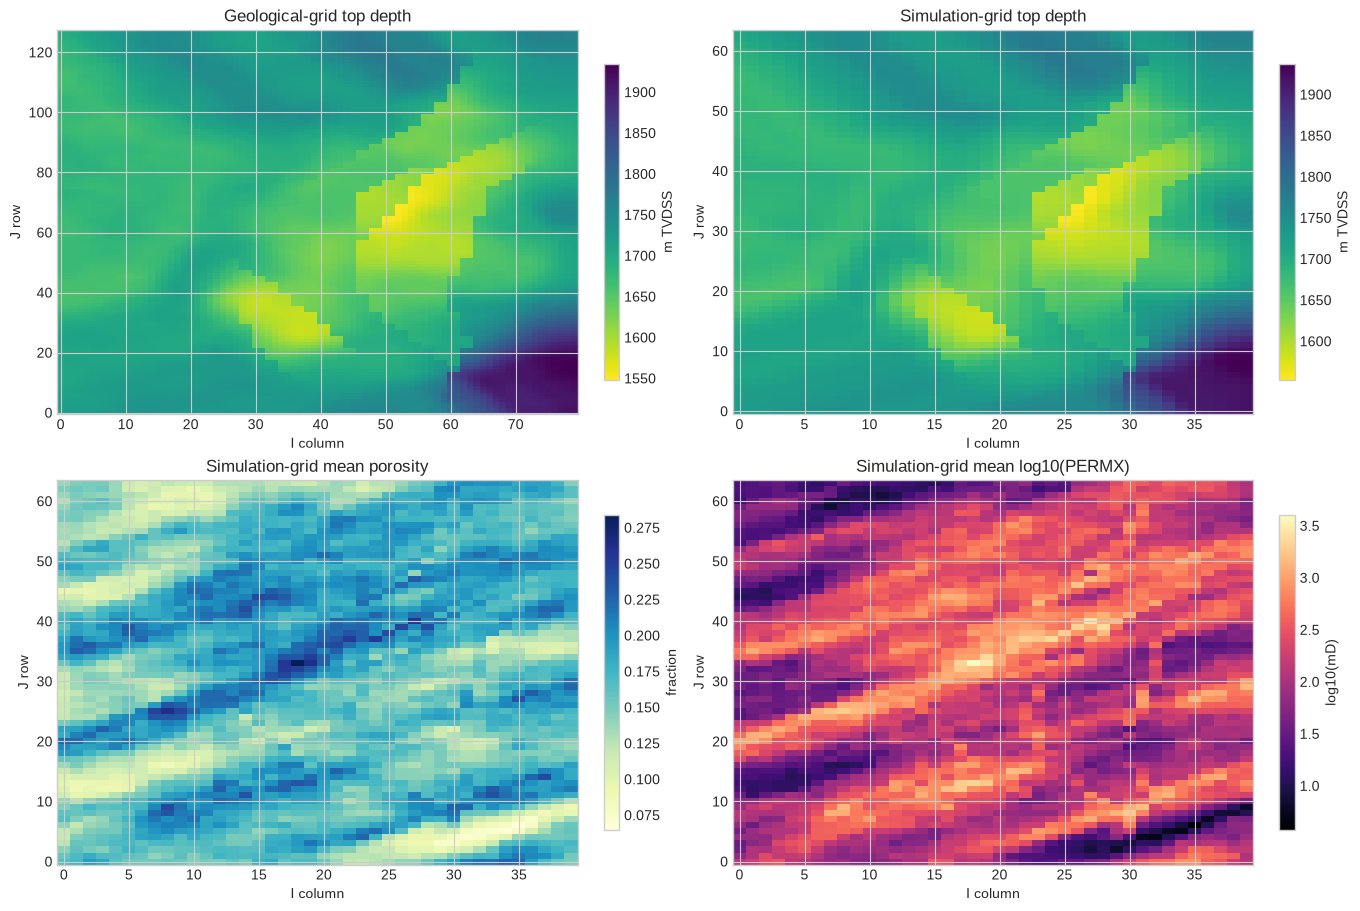

In [8]:
fine_x, fine_y, fine_z = fine_grid.get_xyz()
fine_top = np.ma.filled(fine_z.values[:, :, 0], np.nan)
sim_top = np.ma.filled(sim_z.values[:, :, 0], np.nan)
sim_poro_map = np.nanmean(np.ma.filled(sim_poro.values, np.nan), axis=2)
sim_logk_map = np.nanmean(np.log10(np.ma.filled(sim_permx.values, np.nan)), axis=2)

structure_figure, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), constrained_layout=True)
items = [
    (fine_top.T, "Geological-grid top depth", "viridis_r", "m TVDSS"),
    (sim_top.T, "Simulation-grid top depth", "viridis_r", "m TVDSS"),
    (sim_poro_map.T, "Simulation-grid mean porosity", "YlGnBu", "fraction"),
    (sim_logk_map.T, "Simulation-grid mean log10(PERMX)", "magma", "log10(mD)"),
]
for axis, (array, title, cmap, unit) in zip(axes.ravel(), items):
    image = axis.imshow(array, origin="lower", aspect="auto", cmap=cmap)
    axis.set_title(title)
    axis.set_xlabel("I column")
    axis.set_ylabel("J row")
    structure_figure.colorbar(image, ax=axis, label=unit, shrink=0.82)

path = OUTPUT_DIRECTORY / "reek_structure_and_static_maps.png"
structure_figure.savefig(path, dpi=165, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

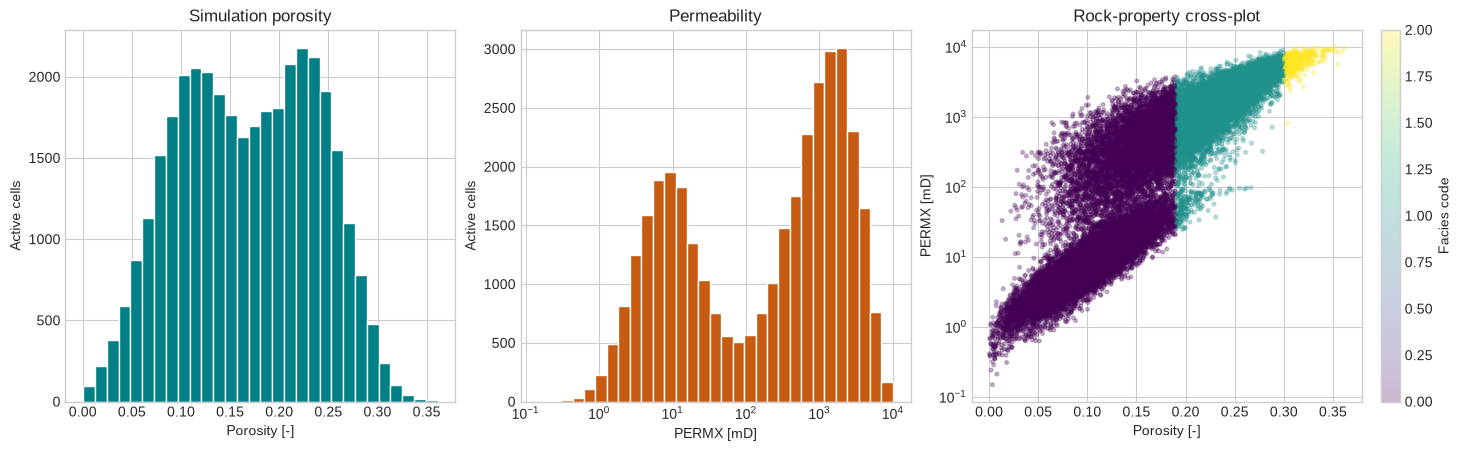

In [9]:
active_poro = sim_poro.values.compressed()
active_permx = sim_permx.values.compressed()
active_facies = sim_facies.values.compressed().astype(int)

distribution_figure, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), constrained_layout=True)
axes[0].hist(active_poro, bins=30, color="#007F87", edgecolor="white")
axes[0].set(xlabel="Porosity [-]", ylabel="Active cells", title="Simulation porosity")
axes[1].hist(active_permx, bins=np.logspace(np.log10(active_permx.min()), np.log10(active_permx.max()), 32),
             color="#C75B12", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set(xlabel="PERMX [mD]", ylabel="Active cells", title="Permeability")
scatter = axes[2].scatter(active_poro, active_permx, c=active_facies, cmap="viridis",
                          s=7, alpha=0.28, rasterized=True)
axes[2].set_yscale("log")
axes[2].set(xlabel="Porosity [-]", ylabel="PERMX [mD]", title="Rock-property cross-plot")
distribution_figure.colorbar(scatter, ax=axes[2], label="Facies code")
path = OUTPUT_DIRECTORY / "reek_property_distributions.png"
distribution_figure.savefig(path, dpi=165, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 3. Blocking and spreading properties

The dimensions reveal an exact 2 × 2 × 4 relationship:

$$
(80,128,56) \rightarrow (40,64,14).
$$

For block B, porosity is pore-volume weighted:

$$
\phi_B = \frac{\sum_{c\in B} \phi_c V_c A_c}
{\sum_{c\in B} V_c A_c},
$$

where V is bulk volume and A is the active-cell indicator. Facies is assigned by the largest
active bulk volume in the block. For teaching, fine Background, Channel, and Crevasse codes are
mapped to simulation SHALE, COARSESAND, and FINESAND codes. This mapping is explicit and is not
claimed to reproduce every hidden RMS workflow setting.

Permeability is not arithmetically averaged here. The supplied simulation PERMX is used because
flow upscaling is directional and depends on boundary conditions. The future RMS job contract
therefore names the approved permeability-upscaling workflow rather than silently inventing one.

In [10]:
BLOCK = (2, 2, 4)
assert (
    fine_grid.ncol // sim_grid.ncol,
    fine_grid.nrow // sim_grid.nrow,
    fine_grid.nlay // sim_grid.nlay,
) == BLOCK

fine_actnum = np.ma.filled(fine_grid.get_actnum().values, 0).astype(bool)
fine_bulk_volume = np.ma.filled(fine_grid.get_bulk_volume().values, 0.0)
fine_poro_values = np.ma.filled(fine_poro.values, 0.0)
fine_facies_values = np.ma.filled(fine_facies.values, 0).astype(int)

def block_sum(array):
    reshaped = array.reshape(
        sim_grid.ncol, BLOCK[0],
        sim_grid.nrow, BLOCK[1],
        sim_grid.nlay, BLOCK[2],
    )
    return reshaped.sum(axis=(1, 3, 5))

active_volume = fine_bulk_volume * fine_actnum
blocked_volume = block_sum(active_volume)
blocked_poro = np.divide(
    block_sum(fine_poro_values * active_volume),
    blocked_volume,
    out=np.full_like(blocked_volume, np.nan, dtype=float),
    where=blocked_volume > 0.0,
)

facies_volume = np.stack([
    block_sum(active_volume * (fine_facies_values == code_value))
    for code_value in [0, 1, 2]
])
fine_majority_facies = np.argmax(facies_volume, axis=0)
fine_to_sim_facies = np.array([0, 2, 1])
blocked_facies = fine_to_sim_facies[fine_majority_facies]

sim_actnum = np.ma.filled(sim_grid.get_actnum().values, 0).astype(bool)
sim_poro_values = np.ma.filled(sim_poro.values, np.nan)
sim_facies_values = np.ma.filled(sim_facies.values, -1).astype(int)
comparison_mask = sim_actnum & np.isfinite(blocked_poro) & np.isfinite(sim_poro_values)

poro_difference = blocked_poro[comparison_mask] - sim_poro_values[comparison_mask]
blocking_metrics = pd.DataFrame({
    "metric": [
        "fine cells per simulation block",
        "porosity RMSE",
        "porosity mean bias",
        "porosity correlation",
        "facies agreement after teaching map",
        "compared active blocks",
    ],
    "value": [
        int(np.prod(BLOCK)),
        float(np.sqrt(np.mean(poro_difference ** 2))),
        float(np.mean(poro_difference)),
        float(np.corrcoef(blocked_poro[comparison_mask], sim_poro_values[comparison_mask])[0, 1]),
        float(np.mean(blocked_facies[comparison_mask] == sim_facies_values[comparison_mask])),
        int(comparison_mask.sum()),
    ],
    "unit": ["fine cells", "fraction", "fraction", "correlation", "fraction", "blocks"],
})
display(blocking_metrics.round(6))

,metric,value,unit
0,fine cells per simulation block,16.000000,fine cells
1,porosity RMSE,0.091877,fraction
2,porosity mean bias,-0.008949,fraction
3,porosity correlation,0.089336,correlation
4,facies agreement after teaching map,0.406870,fraction
5,compared active blocks,35810.000000,blocks


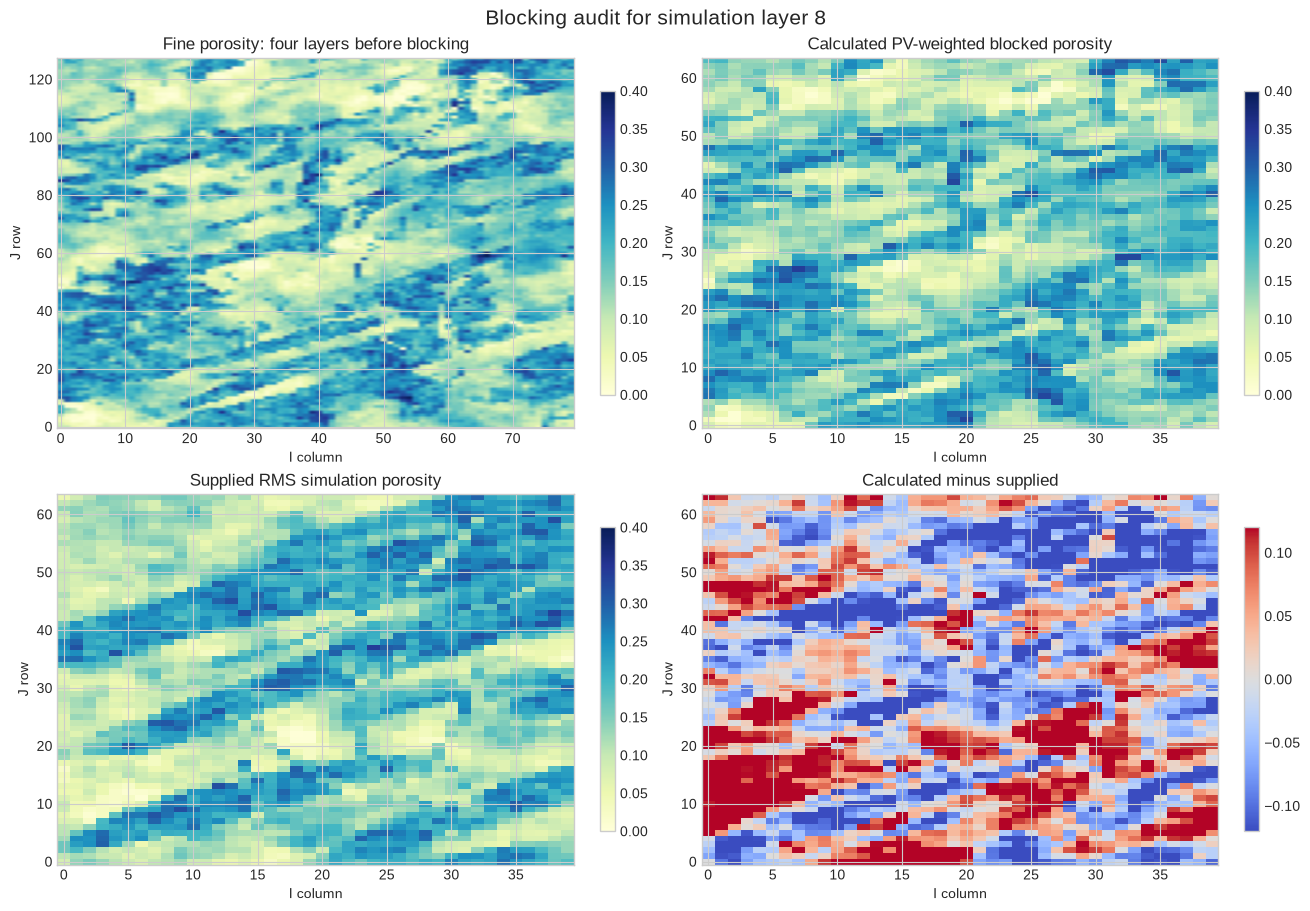

In [11]:
layer_index = sim_grid.nlay // 2
fine_layer_start = layer_index * BLOCK[2]
fine_layer_mean = np.nanmean(
    np.ma.filled(fine_poro.values[:, :, fine_layer_start:fine_layer_start + BLOCK[2]], np.nan),
    axis=2,
)

blocking_figure, axes = plt.subplots(2, 2, figsize=(13.0, 9.0), constrained_layout=True)
arrays = [
    (fine_layer_mean.T, "Fine porosity: four layers before blocking", "YlGnBu", 0.0, 0.40),
    (blocked_poro[:, :, layer_index].T, "Calculated PV-weighted blocked porosity", "YlGnBu", 0.0, 0.40),
    (sim_poro_values[:, :, layer_index].T, "Supplied RMS simulation porosity", "YlGnBu", 0.0, 0.40),
    ((blocked_poro[:, :, layer_index] - sim_poro_values[:, :, layer_index]).T,
     "Calculated minus supplied", "coolwarm", -0.12, 0.12),
]
for axis, (array, title, cmap, vmin, vmax) in zip(axes.ravel(), arrays):
    image = axis.imshow(array, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set(title=title, xlabel="I column", ylabel="J row")
    blocking_figure.colorbar(image, ax=axis, shrink=0.82)
blocking_figure.suptitle(f"Blocking audit for simulation layer {layer_index + 1}", fontsize=15)
path = OUTPUT_DIRECTORY / "reek_blocking_comparison.png"
blocking_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

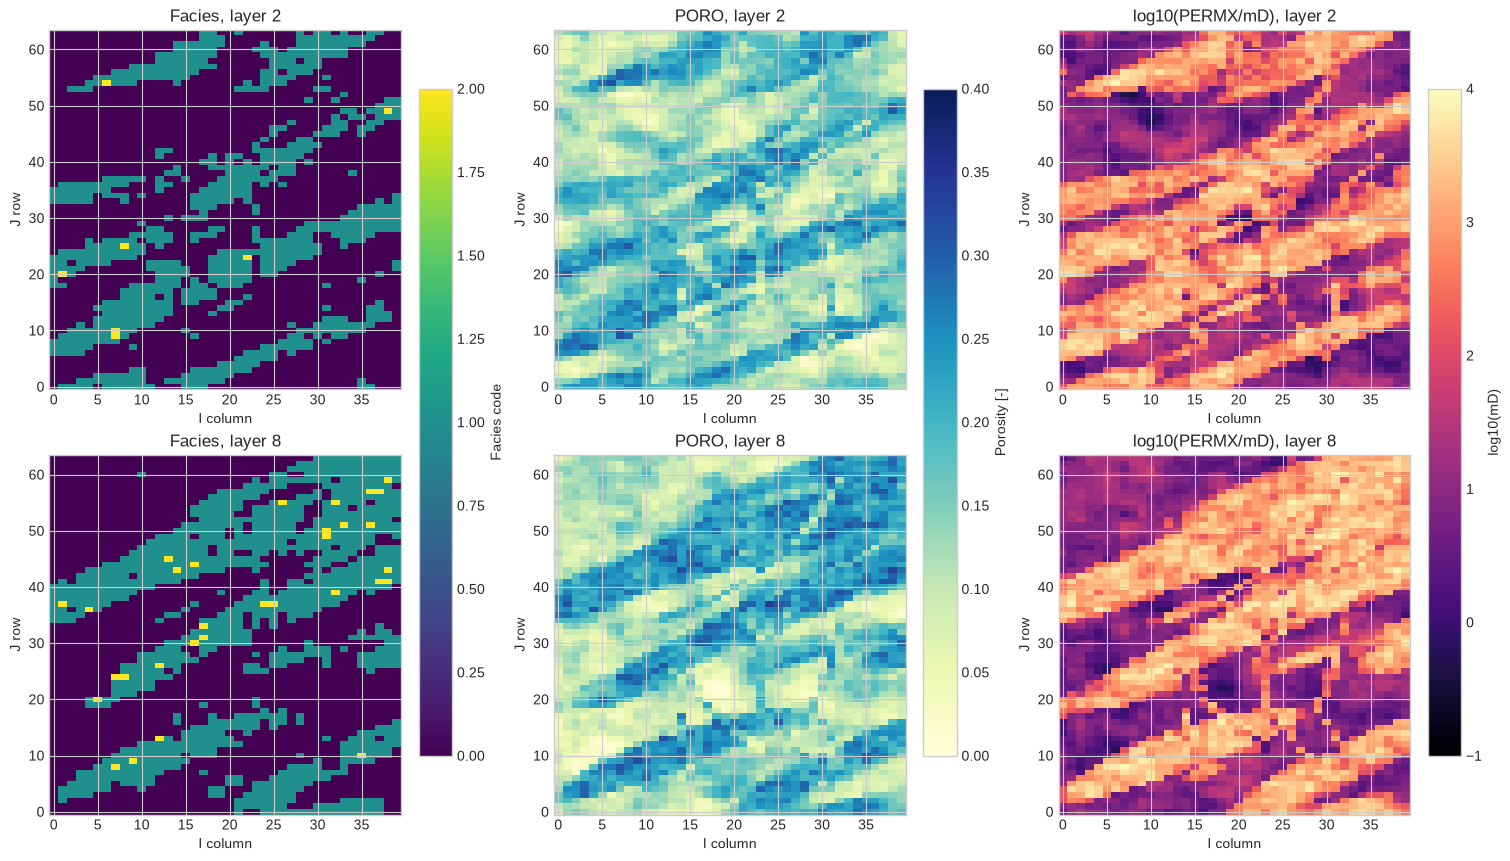

In [12]:
spread_figure, axes = plt.subplots(2, 3, figsize=(15.0, 8.5), constrained_layout=True)
selected_layers = [1, sim_grid.nlay // 2]
facies_colors = "viridis"
for row, k_index in enumerate(selected_layers):
    facies_image = axes[row, 0].imshow(sim_facies_values[:, :, k_index].T, origin="lower",
                                       aspect="auto", cmap=facies_colors, vmin=0, vmax=2)
    axes[row, 0].set_title(f"Facies, layer {k_index + 1}")
    poro_image = axes[row, 1].imshow(sim_poro_values[:, :, k_index].T, origin="lower",
                                     aspect="auto", cmap="YlGnBu", vmin=0.0, vmax=0.4)
    axes[row, 1].set_title(f"PORO, layer {k_index + 1}")
    perm_image = axes[row, 2].imshow(
        np.log10(np.ma.filled(sim_permx.values[:, :, k_index], np.nan)).T,
        origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=4,
    )
    axes[row, 2].set_title(f"log10(PERMX/mD), layer {k_index + 1}")
    for axis in axes[row]:
        axis.set(xlabel="I column", ylabel="J row")
spread_figure.colorbar(facies_image, ax=axes[:, 0], label="Facies code", shrink=0.85)
spread_figure.colorbar(poro_image, ax=axes[:, 1], label="Porosity [-]", shrink=0.85)
spread_figure.colorbar(perm_image, ax=axes[:, 2], label="log10(mD)", shrink=0.85)
path = OUTPUT_DIRECTORY / "reek_property_spreading_layers.png"
spread_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 4. Screen an injector–producer pair

A transparent screening score is used only to place demonstration wells. It combines column
hydrocarbon pore volume with a logarithmic permeability-thickness proxy. The producer uses the
best column. The injector is selected among high-score columns 8–14 Manhattan grid steps away,
which makes the displacement visible without claiming an optimized field-development plan.
Only active layers are completed.

In [13]:
sim_bulk_volume = np.ma.filled(sim_grid.get_bulk_volume().values, 0.0)
sim_perm_values = np.ma.filled(sim_permx.values, 0.0)
INITIAL_WATER_SATURATION = 0.18
column_hcpv = np.sum(sim_bulk_volume * sim_poro_values * (1.0 - INITIAL_WATER_SATURATION), axis=2)
column_kh = np.sum(sim_perm_values * np.ma.filled(sim_dz.values, 0.0), axis=2)
screening_score = column_hcpv * np.log1p(column_kh)
screening_score[~np.any(sim_actnum, axis=2)] = -np.inf

producer_flat = int(np.nanargmax(screening_score))
producer_i, producer_j = np.unravel_index(producer_flat, screening_score.shape)

candidate_order = np.argsort(screening_score.ravel())[::-1]
injector_i = injector_j = None
for flat_index in candidate_order:
    i_index, j_index = np.unravel_index(int(flat_index), screening_score.shape)
    distance = abs(i_index - producer_i) + abs(j_index - producer_j)
    if 8 <= distance <= 14 and np.isfinite(screening_score[i_index, j_index]):
        injector_i, injector_j = i_index, j_index
        break
if injector_i is None:
    raise RuntimeError("No suitable injector column was found.")

producer_layers = np.flatnonzero(sim_actnum[producer_i, producer_j, :]) + 1
injector_layers = np.flatnonzero(sim_actnum[injector_i, injector_j, :]) + 1

well_table = pd.DataFrame([
    {
        "well": "PROD", "I": producer_i + 1, "J": producer_j + 1,
        "first K": int(producer_layers.min()), "last K": int(producer_layers.max()),
        "active completions": len(producer_layers),
        "column HCPV [million rm3]": column_hcpv[producer_i, producer_j] / 1e6,
        "score": screening_score[producer_i, producer_j],
    },
    {
        "well": "WINJ", "I": injector_i + 1, "J": injector_j + 1,
        "first K": int(injector_layers.min()), "last K": int(injector_layers.max()),
        "active completions": len(injector_layers),
        "column HCPV [million rm3]": column_hcpv[injector_i, injector_j] / 1e6,
        "score": screening_score[injector_i, injector_j],
    },
])
display(well_table.round(3))

,well,I,J,first K,last K,active completions,column HCPV [million rm3],score
0,PROD,25,38,1,14,14,0.292,3581725.417
1,WINJ,19,34,1,14,14,0.244,2971149.240


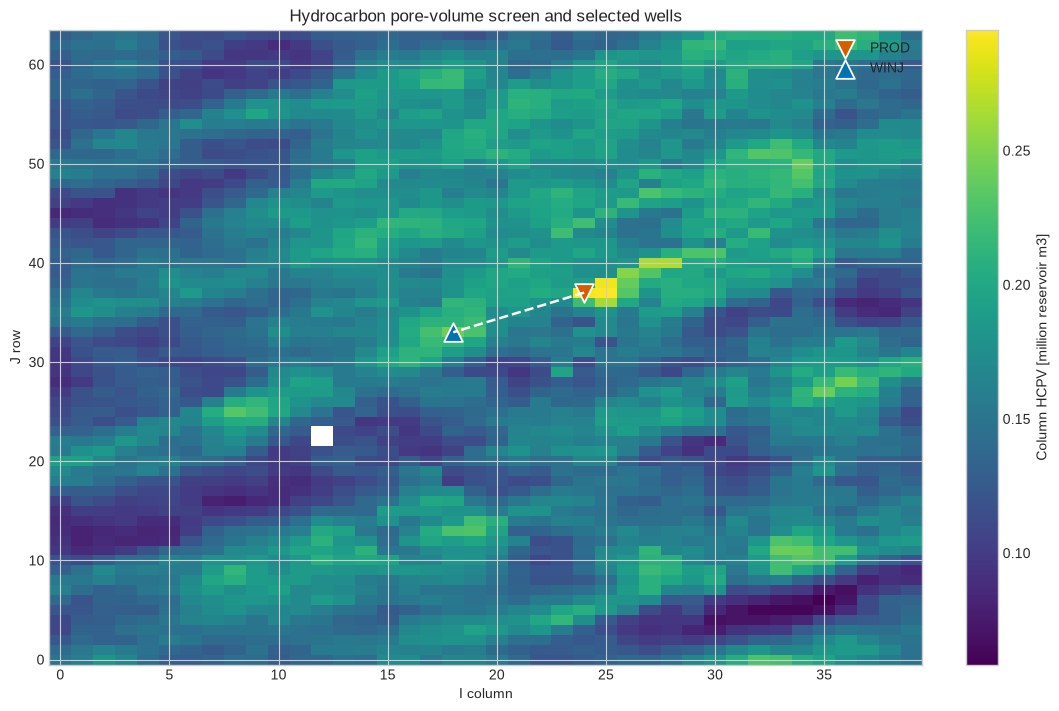

In [14]:
well_figure, axis = plt.subplots(figsize=(10.5, 7.0), constrained_layout=True)
image = axis.imshow((column_hcpv / 1e6).T, origin="lower", aspect="auto", cmap="viridis")
axis.scatter(producer_i, producer_j, marker="v", s=180, color="#D55E00",
             edgecolor="white", linewidth=1.3, label="PROD")
axis.scatter(injector_i, injector_j, marker="^", s=180, color="#0072B2",
             edgecolor="white", linewidth=1.3, label="WINJ")
axis.plot([producer_i, injector_i], [producer_j, injector_j], color="white", linestyle="--", linewidth=1.8)
axis.set(xlabel="I column", ylabel="J row", title="Hydrocarbon pore-volume screen and selected wells")
axis.legend()
well_figure.colorbar(image, ax=axis, label="Column HCPV [million reservoir m3]")
path = OUTPUT_DIRECTORY / "reek_well_screening.png"
well_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 5. Generate black-oil PVT with NeqSim

The composition below is fully visible. NeqSim characterizes the C20+ fraction into twelve
pseudo-components, runs a differential-liberation calculation, derives gas and water
properties, and emits strict Flow tables. The PVT input and every generated table row are
printed, not hidden behind a pre-built include file.

In [15]:
LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]

TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]

PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)


def build_reservoir_fluid():
    fluid_model = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        INITIAL_RESERVOIR_PRESSURE_BARA,
    )

    for component_name, amount_mol_percent in LIGHT_COMPONENTS:
        fluid_model.addComponent(component_name, amount_mol_percent)

    for cut_name, amount, molar_mass, relative_density in TBP_CUTS:
        fluid_model.addTBPfraction(
            cut_name,
            amount,
            molar_mass,
            relative_density,
        )

    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    fluid_model.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )

    characterization = fluid_model.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()

    fluid_model.setMixingRule("classic")
    fluid_model.useVolumeCorrection(True)
    fluid_model.init(0)
    fluid_model.init(1)
    return fluid_model


reservoir_fluid = build_reservoir_fluid()

In [16]:
characterized_rows = []
for component_index in range(reservoir_fluid.getNumberOfComponents()):
    component = reservoir_fluid.getComponent(component_index)
    characterized_rows.append(
        {
            "component": str(component.getComponentName()),
            "mole_fraction": float(component.getz()),
            "molar_mass_g_mol": 1000.0 * float(component.getMolarMass()),
        }
    )

characterized_composition = pd.DataFrame(characterized_rows)
composition_sum = characterized_composition["mole_fraction"].sum()

initial_state = reservoir_fluid.clone()
initial_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
initial_state.setPressure(INITIAL_RESERVOIR_PRESSURE_BARA, "bara")
TPflash(initial_state)
initial_state.initPhysicalProperties()

SaturationPressure = jneqsim.pvtsimulation.simulation.SaturationPressure
saturation_calculation = SaturationPressure(reservoir_fluid.clone())
saturation_calculation.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_calculation.run()
bubble_pressure_reference_bara = (
    saturation_calculation.getSaturationPressure()
)

fluid_audit = pd.DataFrame(
    {
        "quantity": [
            "input assay closure",
            "characterized components",
            "characterized composition sum",
            "initial phase count",
            "bubble pressure",
        ],
        "value": [
            sum(amount for _, amount in LIGHT_COMPONENTS)
            + sum(row[1] for row in TBP_CUTS)
            + PLUS_FRACTION[1],
            reservoir_fluid.getNumberOfComponents(),
            composition_sum,
            initial_state.getNumberOfPhases(),
            bubble_pressure_reference_bara,
        ],
        "unit": ["mol%", "count", "mol/mol", "count", "bara"],
    }
)
display(fluid_audit)
display(characterized_composition)

,quantity,value,unit
0,input assay closure,100.000000,mol%
1,characterized components,22.000000,count
2,characterized composition sum,1.000000,mol/mol
3,initial phase count,1.000000,count
4,bubble pressure,193.240934,bara


,component,mole_fraction,molar_mass_g_mol
0,nitrogen,0.003900,28.013500
1,CO2,0.003000,44.010000
2,methane,0.402000,16.043000
3,ethane,0.076100,30.070000
4,propane,0.079500,44.097000
5,i-butane,0.011900,58.123000
6,n-butane,0.040800,58.123000
7,i-pentane,0.013900,72.151000
8,n-pentane,0.021500,72.150000
9,n-hexane,0.027900,86.177000


In [17]:
DifferentialLiberation = (
    jneqsim.pvtsimulation.simulation.DifferentialLiberation
)
dle = DifferentialLiberation(reservoir_fluid.clone())
dle.setPressures(DLE_PRESSURES_BARA.tolist())
dle.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
dle.runCalc()

bubble_pressure_bara = float(dle.getSaturationPressure())
dle_rs = np.asarray(dle.getRs(), dtype=float)
dle_bo = np.asarray(dle.getBo(), dtype=float)
dle_bg = np.asarray(dle.getBg(), dtype=float)
dle_oil_density_kg_m3 = np.asarray(dle.getOilDensity(), dtype=float)

saturation_gas_state = reservoir_fluid.clone()
saturation_gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_gas_state.setPressure(bubble_pressure_bara * 0.99, "bara")
TPflash(saturation_gas_state)
saturation_gas_state.initPhysicalProperties()
saturation_gas_viscosity_pa_s = (
    saturation_gas_state.getPhase("gas").getViscosity("cP") / 1000.0
)

black_oil_rows = []
for pressure_bara, rs_value, bo_value, bg_value, oil_density in zip(
    DLE_PRESSURES_BARA,
    dle_rs,
    dle_bo,
    dle_bg,
    dle_oil_density_kg_m3,
):
    property_state = reservoir_fluid.clone()
    property_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    property_state.setPressure(float(pressure_bara), "bara")
    TPflash(property_state)
    property_state.initPhysicalProperties()

    oil_viscosity_pa_s = (
        property_state.getPhase("oil").getViscosity("cP") / 1000.0
    )
    if property_state.hasPhaseType("gas"):
        gas_viscosity_pa_s = (
            property_state.getPhase("gas").getViscosity("cP") / 1000.0
        )
    else:
        gas_viscosity_pa_s = saturation_gas_viscosity_pa_s

    black_oil_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Rs_Sm3_Sm3": float(rs_value),
            "Bo_rm3_Sm3": float(bo_value),
            "oil_density_kg_m3": float(oil_density),
            "oil_viscosity_cP": 1000.0 * float(oil_viscosity_pa_s),
            "DLE_Bg_rm3_Sm3": float(bg_value),
            "gas_viscosity_cP": 1000.0 * float(gas_viscosity_pa_s),
        }
    )

black_oil_source_table = pd.DataFrame(black_oil_rows)
display(black_oil_source_table)
print(f"DLE bubble pressure: {bubble_pressure_bara:.6f} bara")

,pressure_bara,Rs_Sm3_Sm3,Bo_rm3_Sm3,oil_density_kg_m3,oil_viscosity_cP,DLE_Bg_rm3_Sm3,gas_viscosity_cP
0,300.00000,224.672710,1.764295,669.030434,0.251013,0.000000,0.021248
1,250.00000,224.672710,1.789529,659.596213,0.235980,0.000000,0.021248
2,220.00000,224.672710,1.806786,653.296398,0.226502,0.000000,0.021248
3,200.00000,224.672710,1.819362,648.780648,0.219967,0.000000,0.021248
4,180.00000,209.018245,1.779299,654.830015,0.230365,0.006301,0.020399
5,150.00000,176.526156,1.687488,672.151168,0.263080,0.007562,0.018454
6,100.00000,128.971246,1.552728,701.626800,0.336558,0.011533,0.015971
7,50.00000,86.277567,1.427528,733.148154,0.461901,0.023873,0.014126
8,1.01325,0.000000,1.050859,810.424578,1.955226,1.271652,0.011572


DLE bubble pressure: 193.240400 bara


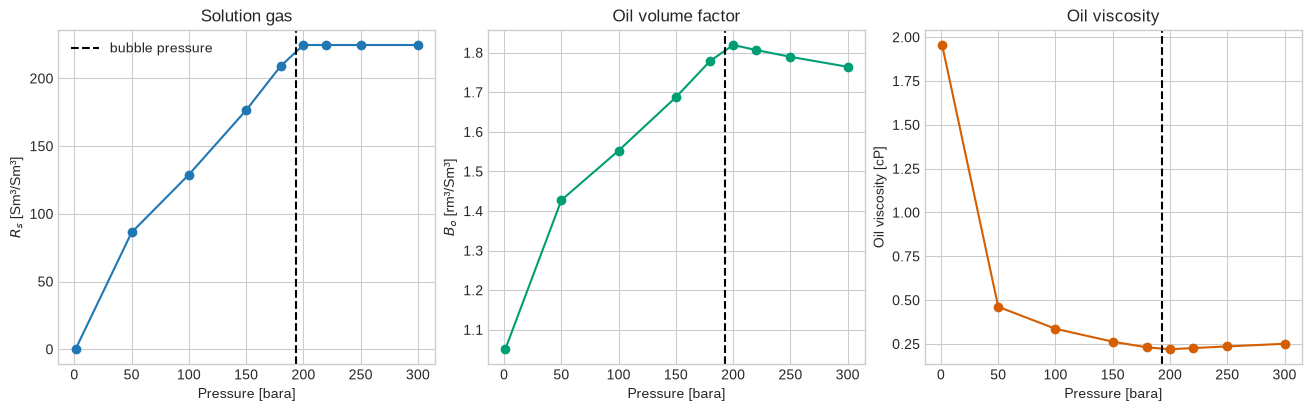

In [18]:
pvt_figure, pvt_axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 4.0),
    constrained_layout=True,
)

pvt_axes[0].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Rs_Sm3_Sm3"],
    marker="o",
)
pvt_axes[0].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="bubble pressure",
)
pvt_axes[0].set_xlabel("Pressure [bara]")
pvt_axes[0].set_ylabel("$R_s$ [Sm³/Sm³]")
pvt_axes[0].set_title("Solution gas")
pvt_axes[0].legend()

pvt_axes[1].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Bo_rm3_Sm3"],
    marker="o",
    color="#009E73",
)
pvt_axes[1].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
)
pvt_axes[1].set_xlabel("Pressure [bara]")
pvt_axes[1].set_ylabel("$B_o$ [rm³/Sm³]")
pvt_axes[1].set_title("Oil volume factor")

pvt_axes[2].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["oil_viscosity_cP"],
    marker="o",
    color="#D55E00",
)
pvt_axes[2].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
)
pvt_axes[2].set_xlabel("Pressure [bara]")
pvt_axes[2].set_ylabel("Oil viscosity [cP]")
pvt_axes[2].set_title("Oil viscosity")

pvt_plot_path = OUTPUT_DIRECTORY / "neqsim_black_oil_pvt.png"
pvt_figure.savefig(pvt_plot_path, dpi=150)
plt.show()
FIGURE_PATHS.append(pvt_plot_path)

In [19]:
stock_tank_state = reservoir_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initPhysicalProperties()

stock_oil_density_kg_m3 = (
    stock_tank_state.getPhase("oil").getDensity("kg/m3")
)
stock_gas_density_kg_m3 = (
    stock_tank_state.getPhase("gas").getDensity("kg/m3")
)

ArrayList = JClass("java.util.ArrayList")
BlackOilPVTTable = JClass("neqsim.blackoil.BlackOilPVTTable")
black_oil_records = ArrayList()
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    black_oil_records.add(
        BlackOilPVTTable.Record(
            row["pressure_bara"],
            row["Rs_Sm3_Sm3"],
            row["Bo_rm3_Sm3"],
            row["oil_viscosity_cP"] / 1000.0,
            max(row["DLE_Bg_rm3_Sm3"], 1.0e-6),
            row["gas_viscosity_cP"] / 1000.0,
            0.0,
            1.0,
            1.0e-3,
        )
    )

black_oil_table = BlackOilPVTTable(
    black_oil_records,
    bubble_pressure_bara,
)

bubble_bo = float(
    np.interp(
        bubble_pressure_bara,
        np.sort(DLE_PRESSURES_BARA),
        dle_bo[np.argsort(DLE_PRESSURES_BARA)],
    )
)
bubble_state = reservoir_fluid.clone()
bubble_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
bubble_state.setPressure(bubble_pressure_bara, "bara")
TPflash(bubble_state)
bubble_state.initPhysicalProperties()
bubble_oil_viscosity_cp = (
    bubble_state.getPhase("oil").getViscosity("cP")
)
maximum_solution_gor = float(np.max(dle_rs))

saturated_oil_rows = []
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    if row["pressure_bara"] >= bubble_pressure_bara:
        continue
    if (
        saturated_oil_rows
        and row["Rs_Sm3_Sm3"] <= saturated_oil_rows[-1]["Rs"]
    ):
        continue
    saturated_oil_rows.append(
        {
            "Rs": max(row["Rs_Sm3_Sm3"], 1.0e-6),
            "pressure": row["pressure_bara"],
            "Bo": row["Bo_rm3_Sm3"],
            "mu_o": row["oil_viscosity_cP"],
        }
    )

saturated_oil_rows.append(
    {
        "Rs": maximum_solution_gor,
        "pressure": bubble_pressure_bara,
        "Bo": bubble_bo,
        "mu_o": bubble_oil_viscosity_cp,
    }
)

maximum_pressure_row = black_oil_source_table.loc[
    black_oil_source_table["pressure_bara"].idxmax()
]
undersaturated_oil_row = {
    "pressure": float(maximum_pressure_row["pressure_bara"]),
    "Bo": float(maximum_pressure_row["Bo_rm3_Sm3"]),
    "mu_o": float(maximum_pressure_row["oil_viscosity_cP"]),
}

In [20]:
stock_gas_template = stock_tank_state.phaseToSystem("gas")
dry_gas_rows = []
for pressure_bara in GAS_PVT_PRESSURES_BARA:
    gas_state = stock_gas_template.clone()
    gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    gas_state.setPressure(float(pressure_bara), "bara")
    TPflash(gas_state)
    gas_state.initPhysicalProperties()
    gas_density_kg_m3 = gas_state.getPhase("gas").getDensity("kg/m3")
    dry_gas_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Bg_rm3_Sm3": (
                stock_gas_density_kg_m3 / gas_density_kg_m3
            ),
            "gas_viscosity_cP": (
                gas_state.getPhase("gas").getViscosity("cP")
            ),
        }
    )

dry_gas_table = pd.DataFrame(dry_gas_rows)


def build_water_state(temperature_c, pressure_bara):
    water_state = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    water_state.addComponent("water", 1.0)
    water_state.setMixingRule(10)
    TPflash(water_state)
    water_state.initPhysicalProperties()
    return water_state


standard_water_state = build_water_state(
    STANDARD_TEMPERATURE_C,
    STANDARD_PRESSURE_BARA,
)
reference_water_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara,
)
water_low_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara - 1.0,
)
water_high_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara + 1.0,
)

stock_water_density_kg_m3 = (
    standard_water_state.getPhase("aqueous").getDensity("kg/m3")
)
reservoir_water_density_kg_m3 = (
    reference_water_state.getPhase("aqueous").getDensity("kg/m3")
)
water_fvf = (
    stock_water_density_kg_m3 / reservoir_water_density_kg_m3
)
water_compressibility_per_bar = (
    water_high_pressure_state.getPhase("aqueous").getDensity("kg/m3")
    - water_low_pressure_state.getPhase("aqueous").getDensity("kg/m3")
) / (2.0 * reservoir_water_density_kg_m3)
water_viscosity_cp = (
    reference_water_state.getPhase("aqueous").getViscosity("cP")
)

display(dry_gas_table)
display(
    pd.DataFrame(
        {
            "water_property": [
                "stock-tank density",
                "reservoir density",
                "formation-volume factor",
                "compressibility",
                "viscosity",
            ],
            "value": [
                stock_water_density_kg_m3,
                reservoir_water_density_kg_m3,
                water_fvf,
                water_compressibility_per_bar,
                water_viscosity_cp,
            ],
            "unit": ["kg/m³", "kg/m³", "rm³/Sm³", "1/bar", "cP"],
        }
    )
)

,pressure_bara,Bg_rm3_Sm3,gas_viscosity_cP
0,1.01325,1.290646,0.012544
1,25.00000,0.049262,0.013143
2,50.00000,0.023145,0.014019
3,75.00000,0.014572,0.015213
4,100.00000,0.010446,0.016778
5,125.00000,0.008134,0.018700
6,150.00000,0.006733,0.020876
7,175.00000,0.005831,0.023164
8,200.00000,0.005216,0.025456
9,225.00000,0.004776,0.027697


,water_property,value,unit
0,stock-tank density,997.784768,kg/m³
1,reservoir density,978.587636,kg/m³
2,formation-volume factor,1.019617,rm³/Sm³
3,compressibility,0.000050,1/bar
4,viscosity,0.296512,cP


In [21]:
pvto_lines = ["PVTO"]
for row_index, row in enumerate(saturated_oil_rows):
    is_last_saturated_row = row_index == len(saturated_oil_rows) - 1
    row_suffix = "" if is_last_saturated_row else " /"
    pvto_lines.append(
        "  "
        f"{row['Rs']:.8f} "
        f"{row['pressure']:.8f} "
        f"{row['Bo']:.8f} "
        f"{row['mu_o']:.8f}"
        f"{row_suffix}"
    )
    if is_last_saturated_row:
        pvto_lines.append(
            "    "
            f"{undersaturated_oil_row['pressure']:.8f} "
            f"{undersaturated_oil_row['Bo']:.8f} "
            f"{undersaturated_oil_row['mu_o']:.8f} /"
        )
pvto_lines.append("/")

pvdg_lines = ["PVDG"]
for row_index, row in dry_gas_table.iterrows():
    row_suffix = " /" if row_index == len(dry_gas_table) - 1 else ""
    pvdg_lines.append(
        "  "
        f"{row['pressure_bara']:.8f} "
        f"{row['Bg_rm3_Sm3']:.10f} "
        f"{row['gas_viscosity_cP']:.8f}"
        f"{row_suffix}"
    )

black_oil_include = "\n".join(
    [
        "-- Flow-compatible black-oil tables calculated with NeqSim",
        "-- Pressure is absolute and the table unit system is METRIC.",
        "DENSITY",
        "  "
        f"{stock_oil_density_kg_m3:.8f} "
        f"{stock_water_density_kg_m3:.8f} "
        f"{stock_gas_density_kg_m3:.8f} /",
        "",
        *pvto_lines,
        "",
        *pvdg_lines,
        "",
        "PVTW",
        "  "
        f"{bubble_pressure_bara:.8f} "
        f"{water_fvf:.8f} "
        f"{water_compressibility_per_bar:.10e} "
        f"{water_viscosity_cp:.8f} "
        "0.0 /",
        "",
    ]
)

black_oil_path = OUTPUT_DIRECTORY / "NEQSIM_PVT.INC"
black_oil_path.write_text(black_oil_include, encoding="utf-8")

oil_table_audit = pd.DataFrame(saturated_oil_rows)
display(oil_table_audit)
print("\n".join(black_oil_include.splitlines()[:42]))
print(f"Black-oil include: {black_oil_path}")

print("\nComplete generated NEQSIM_PVT.INC:\n")
print(black_oil_include)

,Rs,pressure,Bo,mu_o
0,0.000001,1.01325,1.050859,1.955226
1,86.277567,50.00000,1.427528,0.461901
2,128.971246,100.00000,1.552728,0.336558
3,176.526156,150.00000,1.687488,0.263080
4,209.018245,180.00000,1.779299,0.230365
5,224.672710,193.24040,1.805822,0.217716


-- Flow-compatible black-oil tables calculated with NeqSim
-- Pressure is absolute and the table unit system is METRIC.
DENSITY
  832.46987287 997.78476781 1.12375584 /

PVTO
  0.00000100 1.01325000 1.05085900 1.95522636 /
  86.27756659 50.00000000 1.42752753 0.46190091 /
  128.97124554 100.00000000 1.55272761 0.33655787 /
  176.52615626 150.00000000 1.68748770 0.26307966 /
  209.01824465 180.00000000 1.77929947 0.23036455 /
  224.67271009 193.24040031 1.80582153 0.21771608
    300.00000000 1.76429452 0.25101335 /
/

PVDG
  1.01325000 1.2906458622 0.01254417
  25.00000000 0.0492622652 0.01314293
  50.00000000 0.0231449092 0.01401858
  75.00000000 0.0145720509 0.01521278
  100.00000000 0.0104455093 0.01677753
  125.00000000 0.0081343925 0.01870015
  150.00000000 0.0067329734 0.02087585
  175.00000000 0.0058305684 0.02316351
  200.00000000 0.0052160944 0.02545613
  225.00000000 0.0047757014 0.02769676
  250.00000000 0.0044458169 0.02986229
  275.00000000 0.0041894725 0.03194685
  300.000

## 6. Export Flow grid and static properties

The OPM model uses the supplied RMS simulation-scale geometry and properties. The exact modeling
assumptions are:

- PORO and PERMX: supplied public simulation properties;
- PERMY = 0.70 × PERMX;
- PERMZ = 0.10 × PERMX;
- FIPNUM: supplied Zone property;
- initial saturation: equilibrium plus the SWOF endpoint;
- relative permeability: the complete tables printed below.

Each GRDECL include is written by XTGeo and hashed. These generated files plus the immutable ROFF
sources make the complete numerical input reproducible without printing hundreds of thousands
of cell values into the browser.

In [22]:
relative_permeability_tables = '''
SWOF
  0.12  0.00000  1.0000  0.0
  0.20  0.00010  0.8500  0.0
  0.30  0.00100  0.6200  0.0
  0.40  0.00800  0.4000  0.0
  0.50  0.03000  0.2200  0.0
  0.60  0.09000  0.1000  0.0
  0.70  0.22000  0.0300  0.0
  0.80  0.48000  0.0050  0.0
  0.88  1.00000  0.0000  0.0 /

SGOF
  0.00  0.0000  1.0000  0.0
  0.05  0.0020  0.9300  0.0
  0.10  0.0100  0.8000  0.0
  0.20  0.0600  0.5500  0.0
  0.30  0.1600  0.3200  0.0
  0.40  0.3300  0.1500  0.0
  0.50  0.5500  0.0500  0.0
  0.60  0.7800  0.0100  0.0
  0.70  0.9300  0.0010  0.0
  0.88  1.0000  0.0000  0.0 /
'''.strip()
print(relative_permeability_tables)

grid_include_path = OUTPUT_DIRECTORY / "REEK_GRID.GRDECL"
sim_grid.to_file(grid_include_path, fformat="grdecl")

def export_grid_property(source_property, keyword, multiplier=1.0):
    exported = source_property.copy()
    exported.name = keyword
    exported.values = source_property.values * multiplier
    output_path = OUTPUT_DIRECTORY / f"{keyword}.GRDECL"
    exported.to_file(output_path, fformat="grdecl")
    return output_path

poro_path = export_grid_property(sim_poro, "PORO")
permx_path = export_grid_property(sim_permx, "PERMX")
permy_path = export_grid_property(sim_permx, "PERMY", 0.70)
permz_path = export_grid_property(sim_permx, "PERMZ", 0.10)
fipnum_path = export_grid_property(sim_zone, "FIPNUM")

generated_static_paths = [grid_include_path, poro_path, permx_path, permy_path, permz_path, fipnum_path]
generated_static_table = pd.DataFrame([
    {
        "file": path.name,
        "bytes": path.stat().st_size,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    }
    for path in generated_static_paths
])
display(generated_static_table)
print("\nGrid include header:\n", "\n".join(grid_include_path.read_text(encoding="utf-8").splitlines()[:24]))

SWOF
  0.12  0.00000  1.0000  0.0
  0.20  0.00010  0.8500  0.0
  0.30  0.00100  0.6200  0.0
  0.40  0.00800  0.4000  0.0
  0.50  0.03000  0.2200  0.0
  0.60  0.09000  0.1000  0.0
  0.70  0.22000  0.0300  0.0
  0.80  0.48000  0.0050  0.0
  0.88  1.00000  0.0000  0.0 /

SGOF
  0.00  0.0000  1.0000  0.0
  0.05  0.0020  0.9300  0.0
  0.10  0.0100  0.8000  0.0
  0.20  0.0600  0.5500  0.0
  0.30  0.1600  0.3200  0.0
  0.40  0.3300  0.1500  0.0
  0.50  0.5500  0.0500  0.0
  0.60  0.7800  0.0100  0.0
  0.70  0.9300  0.0010  0.0
  0.88  1.0000  0.0000  0.0 /


,file,bytes,sha256
0,REEK_GRID.GRDECL,5576400,f52cc87ee49ae0f715e504910386c67593be7a301d36e8...
1,PORO.GRDECL,471901,bd6e51ace0e867d61c4f72504109bb679e2dfc5124454e...
2,PERMX.GRDECL,471902,885fb2e50c8de23b22efff0b5d27f356bb25a736de2b5f...
3,PERMY.GRDECL,471902,1b6ed1e344aaa150090c01c7f3e883c7005e201990f4b6...
4,PERMZ.GRDECL,471902,2948737c53ad15e1c93d632e1cd90f436dfe113ad35d10...
5,FIPNUM.GRDECL,77663,8de3e8fada8dc2e50075547bfb07e5c1dd2935018e0f41...



Grid include header:
 SPECGRID
 40 64 14 1 F
 /
COORD
 456511.0732421875 5935688.224121094 1726.18701171875 456510.625 5935687.958984375 1769.114990234375
 456651.255859375 5935769.156005859 1726.7149658203125 456651.26708984375 5935769.1630859375 1769.9449462890625
 456791.35302734375 5935850.0419921875 1728.3050537109375 456792.0107421875 5935850.4208984375 1771.9649658203125
 456931.36279296875 5935930.8759765625 1730.2080078125 456932.9091796875 5935931.769042969 1774.0279541015625
 457071.27880859375 5936011.656005859 1732.238037109375 457073.98486328125 5936013.219970703 1776.1810302734375
 457211.09912109375 5936092.381103516 1734.5169677734375 457215.25 5936094.779052734 1778.5789794921875
 457350.81982421875 5936173.049072266 1736.79296875 457356.68994140625 5936176.439941406 1781.0159912109375
 457490.4501953125 5936253.6650390625 1738.490966796875 457498.27392578125 5936258.185058594 1782.98095703125
 457630.04296875 5936334.258056641 1738.9100341796875 457639.9189453125 59

In [23]:
minimum_depth = float(np.ma.min(sim_z.values))
maximum_depth = float(np.ma.max(sim_z.values))
datum_depth = float(np.ma.mean(sim_z.values))
water_contact_depth = maximum_depth + 100.0
gas_contact_depth = minimum_depth - 100.0
initial_rs_sm3_sm3 = saturated_oil_rows[-1]["Rs"]

def completion_lines(well_name, i_index, j_index, layers):
    return "\n".join(
        f"  '{well_name}' {i_index + 1} {j_index + 1} {int(k)} {int(k)} 'OPEN' 1* 1* 0.20 /"
        for k in layers
    )

def render_deck(perm_multiplier, poro_multiplier, injection_rate):
    return f'''
RUNSPEC
TITLE
  PUBLIC RMS-ORIGIN REEK MODEL: NEQSIM PVT, OPM FLOW, ERT

DIMENS
  {sim_grid.ncol} {sim_grid.nrow} {sim_grid.nlay} /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2025 /

WELLDIMS
  2 {max(len(producer_layers), len(injector_layers))} 1 2 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
INCLUDE
  '{grid_include_path.as_posix()}' /
INCLUDE
  '{poro_path.as_posix()}' /
INCLUDE
  '{permx_path.as_posix()}' /
INCLUDE
  '{permy_path.as_posix()}' /
INCLUDE
  '{permz_path.as_posix()}' /

MULTIPLY
  PORO {poro_multiplier} 6* /
  PERMX {perm_multiplier} 6* /
  PERMY {perm_multiplier} 6* /
  PERMZ {perm_multiplier} 6* /
/

PROPS
INCLUDE
  '{black_oil_path.resolve().as_posix()}' /

ROCK
  260.0 4.0E-5 /

{relative_permeability_tables}

REGIONS
INCLUDE
  '{fipnum_path.as_posix()}' /

SOLUTION
EQUIL
  {datum_depth:.6f} {INITIAL_RESERVOIR_PRESSURE_BARA:.6f}
  {water_contact_depth:.6f} 0.0 {gas_contact_depth:.6f} 0.0 1 0 0 /

RSVD
  {minimum_depth:.6f} {initial_rs_sm3_sm3:.8f}
  {maximum_depth:.6f} {initial_rs_sm3_sm3:.8f} /

SUMMARY
FPR
FOPR
FGPR
FWPR
FWIR
FOPT
FGPT
FWPT
WBHP
  'PROD' 'WINJ' /
WGOR
  'PROD' /

SCHEDULE
RPTRST
  'BASIC=1' /

GRUPTREE
  'WELLS' 'FIELD' /
/

WELSPECS
  'PROD' 'WELLS' {producer_i + 1} {producer_j + 1} {datum_depth:.3f} 'OIL' /
  'WINJ' 'WELLS' {injector_i + 1} {injector_j + 1} {datum_depth:.3f} 'WATER' /
/

COMPDAT
{completion_lines("PROD", producer_i, producer_j, producer_layers)}
{completion_lines("WINJ", injector_i, injector_j, injector_layers)}
/

WCONPROD
  'PROD' 'OPEN' 'ORAT' 10000.0 4* {PRODUCER_BHP_LIMIT_BARA:.3f} /
/

WCONINJE
  'WINJ' 'WATER' 'OPEN' 'RATE' {injection_rate} 1* 320.0 /
/

TSTEP
  24*30.4375 /

END
'''.strip()

deck_text = render_deck(1.0, 1.0, 12000.0)
deck_path = OUTPUT_DIRECTORY / "RMS_REEK_BASE.DATA"
deck_path.write_text(deck_text + "\n", encoding="utf-8")
print(deck_text)

RUNSPEC
TITLE
  PUBLIC RMS-ORIGIN REEK MODEL: NEQSIM PVT, OPM FLOW, ERT

DIMENS
  40 64 14 /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2025 /

WELLDIMS
  2 14 1 2 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/REEK_GRID.GRDECL' /
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/PORO.GRDECL' /
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/PERMX.GRDECL' /
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/PERMY.GRDECL' /
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/PERMZ.GRDECL' /

MULTIPLY
  PORO 1.0 6* /
  PERMX 1.0 6* /
  PERMY 1.0 6* /
  PERMZ 1.0 6* /
/

PROPS
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/NEQSIM_PVT.INC' /

ROCK
  260.0 4.0E-5 /

SWOF
  0.12  0

In [24]:
parsed_deck = Parser().parse(str(deck_path))
required_keywords = [
    "DIMENS", "COORD", "ZCORN", "ACTNUM", "PORO", "PERMX", "PERMY", "PERMZ",
    "DENSITY", "PVTO", "PVDG", "PVTW", "EQUIL", "WELSPECS", "COMPDAT",
    "WCONPROD", "WCONINJE",
]
deck_keyword_audit = pd.DataFrame({
    "keyword": required_keywords,
    "present": [keyword in parsed_deck for keyword in required_keywords],
})
oil_table_audit = pd.DataFrame(saturated_oil_rows)
pvt_contract_audit = pd.DataFrame({
    "contract": [
        "saturated Rs strictly increases",
        "bubble pressure strictly increases",
        "dry-gas pressure strictly increases",
        "dry-gas Bg strictly decreases",
        "no invalid numeric tokens",
    ],
    "passed": [
        np.all(np.diff(oil_table_audit["Rs"]) > 0),
        np.all(np.diff(oil_table_audit["pressure"]) > 0),
        np.all(np.diff(dry_gas_table["pressure_bara"]) > 0),
        np.all(np.diff(dry_gas_table["Bg_rm3_Sm3"]) < 0),
        not any(token in black_oil_include for token in ["NaN", "Infinity", "-Infinity"]),
    ],
})
display(deck_keyword_audit)
display(pvt_contract_audit)
if not deck_keyword_audit["present"].all() or not pvt_contract_audit["passed"].all():
    raise AssertionError("Deck or PVT contract validation failed.")
print(f"OPM parser accepted {len(parsed_deck)} expanded keywords.")

,keyword,present
0,DIMENS,True
1,COORD,True
2,ZCORN,True
3,ACTNUM,True
4,PORO,True
5,PERMX,True
6,PERMY,True
7,PERMZ,True
8,DENSITY,True
9,PVTO,True


,contract,passed
0,saturated Rs strictly increases,True
1,bubble pressure strictly increases,True
2,dry-gas pressure strictly increases,True
3,dry-gas Bg strictly decreases,True
4,no invalid numeric tokens,True


OPM parser accepted 56 expanded keywords.


## 7. Run OPM Flow and retain diagnostics

This is the real simulator invocation. It is not a surrogate decline curve. The return code,
reported timing, output files, and log tail are retained. A failed simulator call raises an
exception and prevents publication of an apparently successful notebook.

In [25]:
flow_start = time.perf_counter()
flow_run = subprocess.run(
    [FLOW_EXECUTABLE, deck_path.name],
    cwd=OUTPUT_DIRECTORY,
    env=FLOW_RUN_ENV,
    capture_output=True,
    text=True,
    timeout=1200,
)
flow_elapsed = time.perf_counter() - flow_start
if flow_run.returncode != 0:
    raise RuntimeError(
        "OPM Flow failed:\n" + flow_run.stdout[-8000:] + "\n" + flow_run.stderr[-4000:]
    )
flow_log_tail = "\n".join(flow_run.stdout.splitlines()[-35:])
flow_diagnostics = pd.DataFrame({
    "diagnostic": ["return code", "wall time", "SMSPEC exists", "UNRST exists", "PRT exists"],
    "value": [
        flow_run.returncode,
        flow_elapsed,
        (OUTPUT_DIRECTORY / "RMS_REEK_BASE.SMSPEC").exists(),
        (OUTPUT_DIRECTORY / "RMS_REEK_BASE.UNRST").exists(),
        (OUTPUT_DIRECTORY / "RMS_REEK_BASE.PRT").exists(),
    ],
    "unit": ["-", "s", "boolean", "boolean", "boolean"],
})
display(flow_diagnostics)
print(flow_log_tail)

,diagnostic,value,unit
0,return code,0,-
1,wall time,12.772644,s
2,SMSPEC exists,True,boolean
3,UNRST exists,True,boolean
4,PRT exists,True,boolean



Report step 22/24 at day 669.625/730.5, date = 01-Nov-2026

Starting time step 0, stepsize 30.4375 days, at day 669.625/700.062, date = 01-Nov-2026
Restart file written for report step 22/24, date = 01-Nov-2026 15:00:00
 Newton its= 2, linearizations= 3 (0.1sec), linear its=  3 (0.1sec)

Report step 23/24 at day 700.062/730.5, date = 02-Dec-2026

Starting time step 0, stepsize 30.4375 days, at day 700.062/730.5, date = 02-Dec-2026
Restart file written for report step 23/24, date = 02-Dec-2026 01:30:00
    Oscillating behavior detected: Relaxation set to 0.900000
 Newton its= 5, linearizations= 6 (0.2sec), linear its=  6 (0.4sec)
Restart file written for report step 24/24, date = 01-Jan-2027 12:00:00


================    End of simulation     ===============

Number of MPI processes:         1
Threads per MPI process:         2
Setup time:                      0.55 s
  Deck input:                    0.20 s
Number of timesteps:            27
Simulation time:                11.75 s
  As

In [26]:
flow_summary = ESmry(str(OUTPUT_DIRECTORY / "RMS_REEK_BASE.SMSPEC"))
def summary_values(key):
    return np.asarray(flow_summary[key], dtype=float)

reservoir_history = pd.DataFrame({
    "date": pd.to_datetime(flow_summary.dates()),
    "time_days": summary_values("TIME"),
    "field_pressure_bara": summary_values("FPR"),
    "oil_rate_Sm3_day": summary_values("FOPR"),
    "gas_rate_Sm3_day": summary_values("FGPR"),
    "water_rate_Sm3_day": summary_values("FWPR"),
    "water_injection_Sm3_day": summary_values("FWIR"),
    "cumulative_oil_MSm3": summary_values("FOPT") / 1e6,
    "cumulative_gas_GSm3": summary_values("FGPT") / 1e9,
    "cumulative_water_MSm3": summary_values("FWPT") / 1e6,
    "producer_bhp_bara": summary_values("WBHP:PROD"),
    "well_gor_Sm3_Sm3": summary_values("WGOR:PROD"),
})
display(reservoir_history)

,date,time_days,field_pressure_bara,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,water_injection_Sm3_day,cumulative_oil_MSm3,cumulative_gas_GSm3,cumulative_water_MSm3,producer_bhp_bara,well_gor_Sm3_Sm3
0,2025-01-02 00:00:00,1.0000,259.668884,10000.0,2246727.0,0.001513,12000.0,0.010000,0.002247,1.512924e-09,249.359833,224.672714
1,2025-01-05 00:00:00,4.0000,259.522766,10000.0,2246727.0,0.002281,12000.0,0.040000,0.008987,8.356746e-09,245.149246,224.672714
2,2025-01-14 00:00:00,13.0000,259.084015,10000.0,2246727.0,0.002682,12000.0,0.130000,0.029207,3.249741e-08,242.938095,224.672714
3,2025-01-31 10:30:00,30.4375,258.233978,10000.0,2246727.0,0.002950,12000.0,0.304375,0.068385,8.394567e-08,241.457336,224.672714
4,2025-03-02 21:00:00,60.8750,256.748932,10000.0,2246727.0,0.003288,12000.0,0.608750,0.136770,1.840319e-07,239.587173,224.672714
5,2025-04-02 07:30:00,91.3125,255.262131,10000.0,2246727.0,0.003596,12000.0,0.913125,0.205154,2.934751e-07,237.877884,224.672714
6,2025-05-02 18:00:00,121.7500,253.773575,10000.0,2246727.0,0.003887,12000.0,1.217500,0.273539,4.118004e-07,236.249237,224.672714
7,2025-06-02 04:30:00,152.1875,252.283218,10000.0,2246727.0,0.004171,12000.0,1.521875,0.341924,5.387495e-07,234.662354,224.672714
8,2025-07-02 15:00:00,182.6250,250.791077,10000.0,2246727.0,0.004451,12000.0,1.826250,0.410309,6.742363e-07,233.085846,224.672714
9,2025-08-02 01:30:00,213.0625,249.297150,10000.0,2246727.0,0.004729,12000.0,2.130625,0.478693,8.181660e-07,231.521439,224.672714


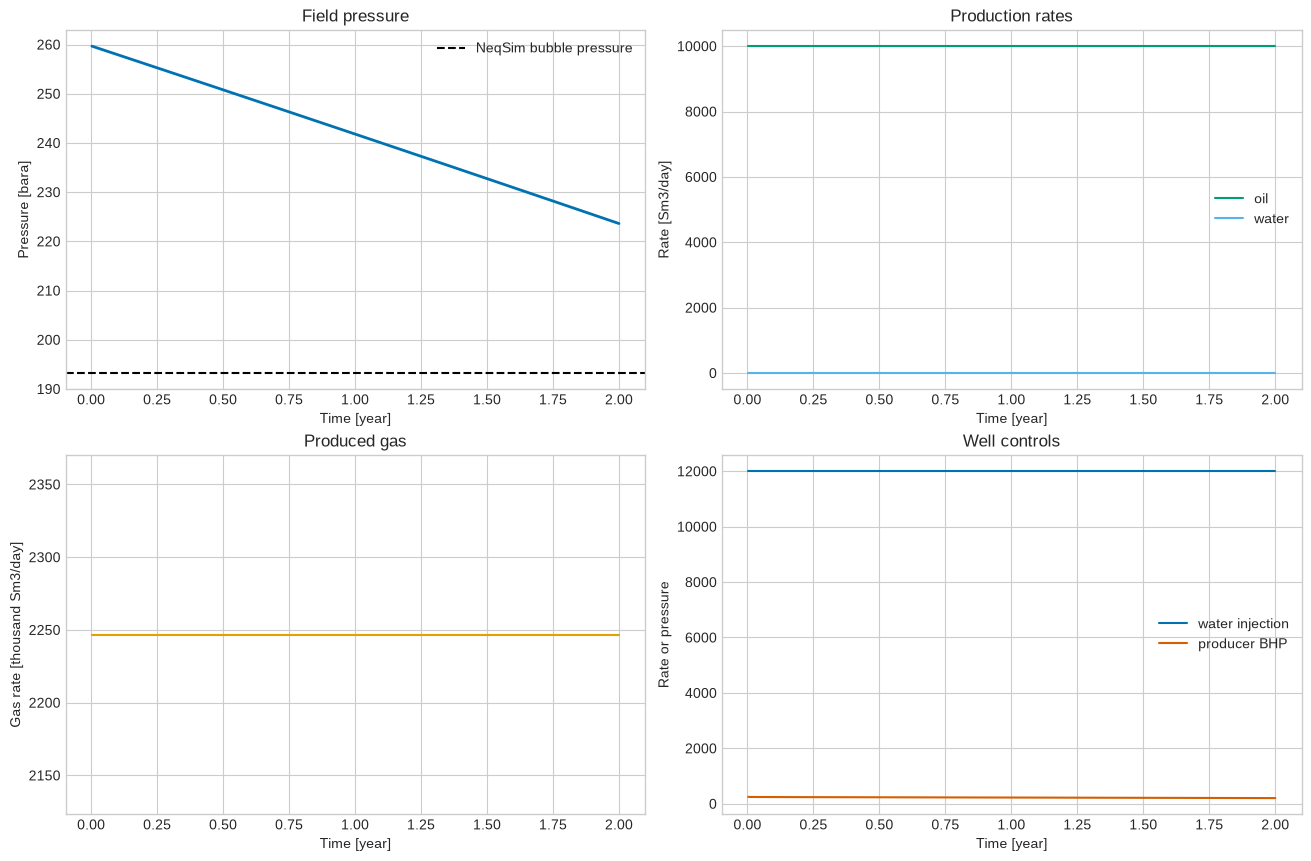

In [27]:
forecast_figure, axes = plt.subplots(2, 2, figsize=(13.0, 8.5), constrained_layout=True)
years = reservoir_history["time_days"] / 365.25
axes[0, 0].plot(years, reservoir_history["field_pressure_bara"], color="#0072B2", linewidth=2)
axes[0, 0].axhline(bubble_pressure_bara, color="black", linestyle="--", label="NeqSim bubble pressure")
axes[0, 0].set(xlabel="Time [year]", ylabel="Pressure [bara]", title="Field pressure")
axes[0, 0].legend()
axes[0, 1].plot(years, reservoir_history["oil_rate_Sm3_day"], label="oil", color="#009E73")
axes[0, 1].plot(years, reservoir_history["water_rate_Sm3_day"], label="water", color="#56B4E9")
axes[0, 1].set(xlabel="Time [year]", ylabel="Rate [Sm3/day]", title="Production rates")
axes[0, 1].legend()
axes[1, 0].plot(years, reservoir_history["gas_rate_Sm3_day"] / 1e3, color="#E69F00")
axes[1, 0].set(xlabel="Time [year]", ylabel="Gas rate [thousand Sm3/day]", title="Produced gas")
axes[1, 1].plot(years, reservoir_history["water_injection_Sm3_day"], color="#0072B2", label="water injection")
axes[1, 1].plot(years, reservoir_history["producer_bhp_bara"], color="#D55E00", label="producer BHP")
axes[1, 1].set(xlabel="Time [year]", ylabel="Rate or pressure", title="Well controls")
axes[1, 1].legend()
path = OUTPUT_DIRECTORY / "opm_flow_forecast.png"
forecast_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 8. Read real restart states and visualize displacement

OPM writes EGRID, INIT, and UNRST. The two inactive simulation cells are handled explicitly:
active vectors are inserted into an I-fastest global array before conversion to K, J, I plotting
order. This prevents the common mistake of reshaping an active vector as if every cell were live.

In [28]:
reservoir_grid = EGrid(str(OUTPUT_DIRECTORY / "RMS_REEK_BASE.EGRID"))
initialization_file = EclFile(str(OUTPUT_DIRECTORY / "RMS_REEK_BASE.INIT"))
restart_file = ERst(str(OUTPUT_DIRECTORY / "RMS_REEK_BASE.UNRST"))
restart_steps = [int(step) for step in restart_file.report_steps]
final_restart_step = restart_steps[-1]

grid_nx, grid_ny, grid_nz = [int(value) for value in reservoir_grid.dimension]
active_cell_count = int(reservoir_grid.active_cells)
act_flat = sim_actnum.ravel(order="F")

def active_to_kji(active_values):
    active_values = np.asarray(active_values, dtype=float)
    if active_values.size != act_flat.sum():
        raise ValueError(f"Expected {act_flat.sum()} active values, received {active_values.size}")
    global_flat = np.full(act_flat.size, np.nan)
    global_flat[act_flat] = active_values
    ijk = global_flat.reshape((grid_nx, grid_ny, grid_nz), order="F")
    return np.transpose(ijk, (2, 1, 0))

permeability_cube_md = active_to_kji(initialization_file["PERMX"])
final_pressure_cube_bara = active_to_kji(restart_file["PRESSURE", final_restart_step])
final_water_saturation_cube = active_to_kji(restart_file["SWAT", final_restart_step])
final_gas_saturation_cube = active_to_kji(restart_file["SGAS", final_restart_step])
final_oil_saturation_cube = 1.0 - final_water_saturation_cube - final_gas_saturation_cube

restart_audit = pd.DataFrame({
    "quantity": ["dimensions", "active cells", "restart states", "pressure range", "SWAT range", "SGAS range", "minimum SOIL"],
    "value": [
        f"{grid_nx} × {grid_ny} × {grid_nz}",
        active_cell_count,
        len(restart_steps),
        f"{np.nanmin(final_pressure_cube_bara):.3f} to {np.nanmax(final_pressure_cube_bara):.3f}",
        f"{np.nanmin(final_water_saturation_cube):.4f} to {np.nanmax(final_water_saturation_cube):.4f}",
        f"{np.nanmin(final_gas_saturation_cube):.4f} to {np.nanmax(final_gas_saturation_cube):.4f}",
        float(np.nanmin(final_oil_saturation_cube)),
    ],
})
display(restart_audit)

,quantity,value
0,dimensions,40 × 64 × 14
1,active cells,35838
2,restart states,25
3,pressure range,198.170 to 242.894
4,SWAT range,0.1168 to 0.8800
5,SGAS range,0.0000 to 0.0000
6,minimum SOIL,0.120037


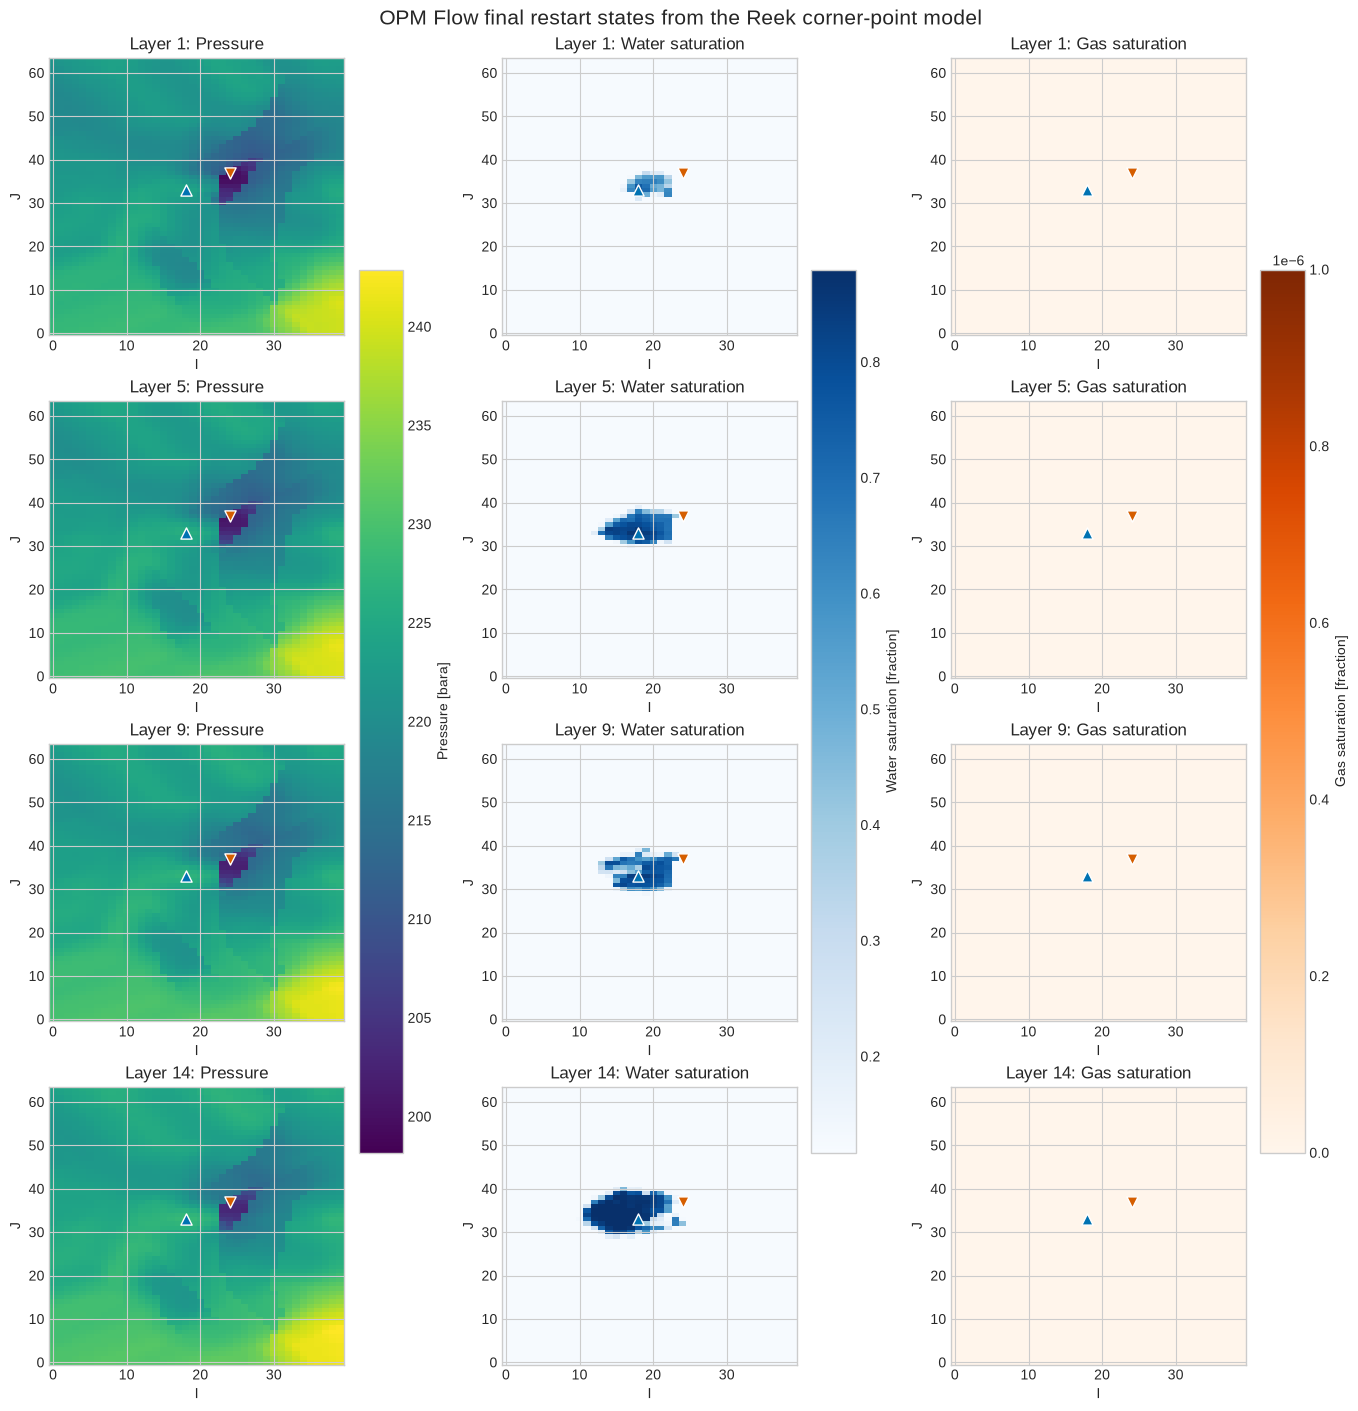

In [29]:
layers_to_plot = np.unique(np.linspace(0, grid_nz - 1, 4, dtype=int))
state_map_figure, axes = plt.subplots(len(layers_to_plot), 3, figsize=(13.5, 14.0), constrained_layout=True)
definitions = [
    (final_pressure_cube_bara, "Pressure", "bara", "viridis"),
    (final_water_saturation_cube, "Water saturation", "fraction", "Blues"),
    (final_gas_saturation_cube, "Gas saturation", "fraction", "Oranges"),
]
images = []
for column, (cube, label, unit, cmap) in enumerate(definitions):
    vmin, vmax = np.nanmin(cube), np.nanmax(cube)
    if np.isclose(vmin, vmax):
        vmin = max(0.0, float(vmin))
        vmax = vmin + 1.0e-6
    for row, k_index in enumerate(layers_to_plot):
        image = axes[row, column].imshow(cube[k_index], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
        if row == 0:
            images.append(image)
        axes[row, column].scatter(producer_i, producer_j, marker="v", s=65, color="#D55E00", edgecolor="white")
        axes[row, column].scatter(injector_i, injector_j, marker="^", s=65, color="#0072B2", edgecolor="white")
        axes[row, column].set(title=f"Layer {k_index + 1}: {label}", xlabel="I", ylabel="J")
    state_map_figure.colorbar(images[column], ax=axes[:, column], label=f"{label} [{unit}]", shrink=0.82)
state_map_figure.suptitle("OPM Flow final restart states from the Reek corner-point model", fontsize=15)
path = OUTPUT_DIRECTORY / "opm_final_restart_maps.png"
state_map_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

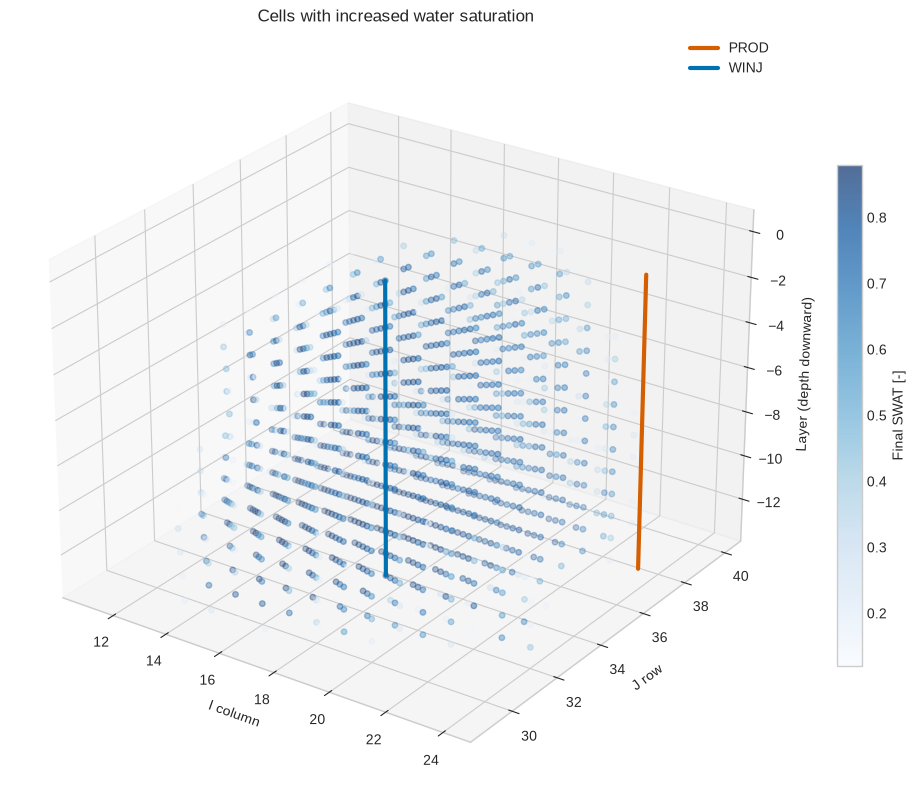

In [30]:
water_increment = final_water_saturation_cube - 0.12
candidate_mask = np.isfinite(water_increment) & (water_increment > 0.015)
k_indices, j_indices, i_indices = np.where(candidate_mask)
if len(i_indices) > 8000:
    rng = np.random.default_rng(RANDOM_SEED)
    keep = rng.choice(len(i_indices), 8000, replace=False)
    i_indices, j_indices, k_indices = i_indices[keep], j_indices[keep], k_indices[keep]

front_figure = plt.figure(figsize=(11.5, 8.0), constrained_layout=True)
axis = front_figure.add_subplot(111, projection="3d")
colors = final_water_saturation_cube[k_indices, j_indices, i_indices]
scatter = axis.scatter(i_indices, j_indices, -k_indices, c=colors, cmap="Blues",
                       vmin=0.12, vmax=max(0.2, float(np.nanmax(final_water_saturation_cube))),
                       s=16, alpha=0.7)
axis.plot([producer_i] * grid_nz, [producer_j] * grid_nz, -np.arange(grid_nz), color="#D55E00", linewidth=3, label="PROD")
axis.plot([injector_i] * grid_nz, [injector_j] * grid_nz, -np.arange(grid_nz), color="#0072B2", linewidth=3, label="WINJ")
axis.set(xlabel="I column", ylabel="J row", zlabel="Layer (depth downward)", title="Cells with increased water saturation")
axis.legend()
front_figure.colorbar(scatter, ax=axis, label="Final SWAT [-]", shrink=0.65)
axis.view_init(elev=26, azim=-55)
path = OUTPUT_DIRECTORY / "opm_3d_water_front.png"
front_figure.savefig(path, dpi=175, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 9. Agent contract: fixture today, licensed RMS worker later

An agent should not receive unrestricted shell access to an RMS workstation. It should submit a
typed job to an allow-listed service. The service validates project identity, workflow name,
grid model, properties, output location, resource limits, and approval policy. It returns signed
artifacts and a structured ledger.

The fixture backend below is actually exercised: it verifies the exported artifacts, blocking
contract, Flow run, and ERT run. A production RMS adapter would implement the same methods with
the RMS Python API inside a licensed environment. Human approval should remain mandatory for
publishing project changes, overwriting realizations, or promoting a model to decision use.

In [31]:
agent_job = {
    "schema": "com.neqsim.reservoir-job/v1",
    "job_id": "reek-public-rms-opm-ert-20260831",
    "mode": "public_fixture",
    "source": {
        "kind": "rms_export",
        "repository": "equinor/xtgeo-testdata",
        "commit": DATA_COMMIT,
        "project_alias": "REEK_PUBLIC",
    },
    "requested_tools": [
        "rms.inspect_project", "rms.run_workflow", "rms.export_grid",
        "rms.export_properties", "neqsim.generate_pvt", "opm.validate",
        "opm.run", "ert.ensemble_experiment",
    ],
    "rms": {
        "workflow_allowlist": ["REEK_BLOCK_AND_EXPORT_V1"],
        "grid_model": "REEK_SIM",
        "properties": ["PORO", "PERMX", "FACIES", "Zone"],
        "blocking": {"i": 2, "j": 2, "k": 4},
        "write_policy": "new_realization_only",
    },
    "flow": {"simulator": "opm-flow", "forecast_months": 24},
    "ert": {"realizations": 4, "max_parallel": 2, "random_seed": RANDOM_SEED},
    "security": {
        "network_egress": "deny_except_artifact_registry",
        "secrets": "worker_identity_only",
        "human_approval": ["overwrite_rms", "publish_decision_model"],
    },
    "acceptance": {
        "all_hashes_verified": True,
        "simulator_return_code": 0,
        "ensemble_realizations": 4,
        "engineering_assertions": "all_pass",
    },
}

class AgentToolLedger:
    def __init__(self, job):
        self.job = job
        self.records = []

    def record(self, tool, status, evidence):
        entry = {
            "sequence": len(self.records) + 1,
            "tool": tool,
            "status": status,
            "evidence": evidence,
        }
        self.records.append(entry)
        return entry

    def frame(self):
        return pd.DataFrame(self.records)

agent_ledger = AgentToolLedger(agent_job)
agent_ledger.record("rms.inspect_project", "fixture_passed", {
    "data_commit": DATA_COMMIT,
    "verified_files": int(download_table["verified"].sum()),
})
agent_ledger.record("rms.run_workflow", "fixture_passed", {
    "workflow": "REEK_BLOCK_AND_EXPORT_V1",
    "blocking": list(BLOCK),
    "fine_cells": fine_grid.ntotal,
    "simulation_cells": sim_grid.ntotal,
})
agent_ledger.record("rms.export_grid", "fixture_passed", {
    "grid_sha256": generated_static_table.loc[generated_static_table["file"] == "REEK_GRID.GRDECL", "sha256"].iloc[0],
})
agent_ledger.record("neqsim.generate_pvt", "passed", {
    "source_commit": neqsim_commit,
    "bubble_pressure_bara": float(bubble_pressure_bara),
    "pvt_sha256": hashlib.sha256(black_oil_path.read_bytes()).hexdigest(),
})
agent_ledger.record("opm.validate", "passed", {
    "keywords": int(deck_keyword_audit["present"].sum()),
})
agent_ledger.record("opm.run", "passed", {
    "return_code": flow_run.returncode,
    "restart_steps": len(restart_steps),
})
job_path = OUTPUT_DIRECTORY / "agent_job.json"
job_path.write_text(json.dumps(agent_job, indent=2) + "\n", encoding="utf-8")
display(agent_ledger.frame())
print(json.dumps(agent_job, indent=2))

,sequence,tool,status,evidence
0,1,rms.inspect_project,fixture_passed,{'data_commit': 'cad17f24e22c19c6cefe6f6471853...
1,2,rms.run_workflow,fixture_passed,"{'workflow': 'REEK_BLOCK_AND_EXPORT_V1', 'bloc..."
2,3,rms.export_grid,fixture_passed,{'grid_sha256': 'f52cc87ee49ae0f715e504910386c...
3,4,neqsim.generate_pvt,passed,{'source_commit': '1f7a01b06307d9d56451e43bb8d...
4,5,opm.validate,passed,{'keywords': 17}
5,6,opm.run,passed,"{'return_code': 0, 'restart_steps': 25}"


{
  "schema": "com.neqsim.reservoir-job/v1",
  "job_id": "reek-public-rms-opm-ert-20260831",
  "mode": "public_fixture",
  "source": {
    "kind": "rms_export",
    "repository": "equinor/xtgeo-testdata",
    "commit": "cad17f24e22c19c6cefe6f647185395cc0a11add",
    "project_alias": "REEK_PUBLIC"
  },
  "requested_tools": [
    "rms.inspect_project",
    "rms.run_workflow",
    "rms.export_grid",
    "rms.export_properties",
    "neqsim.generate_pvt",
    "opm.validate",
    "opm.run",
    "ert.ensemble_experiment"
  ],
  "rms": {
    "workflow_allowlist": [
      "REEK_BLOCK_AND_EXPORT_V1"
    ],
    "grid_model": "REEK_SIM",
    "properties": [
      "PORO",
      "PERMX",
      "FACIES",
      "Zone"
    ],
    "blocking": {
      "i": 2,
      "j": 2,
      "k": 4
    },
    "write_policy": "new_realization_only"
  },
  "flow": {
    "simulator": "opm-flow",
    "forecast_months": 24
  },
  "ert": {
    "realizations": 4,
    "max_parallel": 2,
    "random_seed": 20260831
  },
  "s

### Licensed RMS adapter pattern

A production worker implements the same contract approximately as follows:

1. Resolve the approved project alias to a server-side path; never accept an arbitrary path.
2. Open the project read-only and inspect the named grid/property inventory.
3. Create a new realization or approved scratch case.
4. Execute only the allow-listed RMS workflow REEK_BLOCK_AND_EXPORT_V1.
5. Export grid and named properties to a job-specific staging directory.
6. Calculate SHA-256, write a manifest, close RMS, and upload signed artifacts.
7. Trigger the same XTGeo, NeqSim, OPM Flow, and ERT validators shown here.
8. Return artifact URIs, logs, resolved software versions, and approval state.

This separation lets an LLM plan and monitor work without giving it raw access to license files,
project directories, or destructive APIs.

## 10. Configure and run ERT with OPM Flow

ERT samples three transparent uncertainties:

| Parameter | Distribution | Meaning |
|---|---:|---|
| PERM_MULT | Uniform 0.70–1.30 | multiplies PERMX, PERMY, PERMZ |
| PORO_MULT | Uniform 0.95–1.05 | multiplies PORO |
| INJ_RATE | Uniform 8,000–16,000 Sm3/day | water-injection target |

TEMPLATE_RENDER writes one complete Flow deck per realization. The standard ERT FLOW forward
model runs the real simulator. Four realizations are deliberately small enough for Colab but use
the same directory and parameter contracts as a larger study. Oil remains on its 10,000 Sm3/day
ORAT control in this short forecast, so the ensemble graphics focus on sampled injection,
pressure response, and the developing produced-water response rather than magnifying tiny
floating-point differences in the controlled oil rate.

In [32]:
parameter_priors = '''PERM_MULT UNIFORM 0.70 1.30
PORO_MULT UNIFORM 0.95 1.05
INJ_RATE UNIFORM 8000.0 16000.0
'''
(ERT_DIRECTORY / "parameters.txt").write_text(parameter_priors, encoding="utf-8")

template_text = render_deck(
    "{{parameters.PERM_MULT.value}}",
    "{{parameters.PORO_MULT.value}}",
    "{{parameters.INJ_RATE.value}}",
)
template_path = ERT_DIRECTORY / "RMS_REEK.DATA.jinja2"
template_path.write_text(template_text + "\n", encoding="utf-8")

ert_configuration = f'''
NUM_REALIZATIONS 4
MIN_REALIZATIONS 4
RANDOM_SEED {RANDOM_SEED}

QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2

RUNPATH runs/realization-<IENS>/iter-<ITER>
ECLBASE RMS_REEK
SUMMARY FPR FOPR FGPR FWPR FWIR FOPT FGPT FWPT WBHP:PROD WGOR:PROD

GEN_KW PARAMETERS parameters.txt

FORWARD_MODEL TEMPLATE_RENDER(<INPUT_FILES>=parameters.json, <TEMPLATE_FILE>=<CONFIG_PATH>/RMS_REEK.DATA.jinja2, <OUTPUT_FILE>=RMS_REEK.DATA)
FORWARD_MODEL FLOW
'''
ert_configuration = textwrap.dedent(ert_configuration).strip() + "\n"
ert_config_path = ERT_DIRECTORY / "rms_reek.ert"
ert_config_path.write_text(ert_configuration, encoding="utf-8")

print("Parameter priors:\n", parameter_priors)
print("ERT configuration:\n", ert_configuration)
print("Rendered deck template (complete):\n", template_text)

Parameter priors:
 PERM_MULT UNIFORM 0.70 1.30
PORO_MULT UNIFORM 0.95 1.05
INJ_RATE UNIFORM 8000.0 16000.0

ERT configuration:
 NUM_REALIZATIONS 4
MIN_REALIZATIONS 4
RANDOM_SEED 20260831

QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2

RUNPATH runs/realization-<IENS>/iter-<ITER>
ECLBASE RMS_REEK
SUMMARY FPR FOPR FGPR FWPR FWIR FOPT FGPT FWPT WBHP:PROD WGOR:PROD

GEN_KW PARAMETERS parameters.txt

FORWARD_MODEL TEMPLATE_RENDER(<INPUT_FILES>=parameters.json, <TEMPLATE_FILE>=<CONFIG_PATH>/RMS_REEK.DATA.jinja2, <OUTPUT_FILE>=RMS_REEK.DATA)
FORWARD_MODEL FLOW

Rendered deck template (complete):
 RUNSPEC
TITLE
  PUBLIC RMS-ORIGIN REEK MODEL: NEQSIM PVT, OPM FLOW, ERT

DIMENS
  40 64 14 /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2025 /

WELLDIMS
  2 14 1 2 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/REEK_GRID.GRDECL' /
INCLUDE
  '/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoi

In [33]:
ert_lint = subprocess.run(
    ["ert", "lint", ert_config_path.name],
    cwd=ERT_DIRECTORY,
    capture_output=True,
    text=True,
    timeout=180,
)
print(ert_lint.stdout)
if ert_lint.stderr:
    print(ert_lint.stderr)
if ert_lint.returncode != 0:
    raise RuntimeError("ERT lint failed.")

ert_start = time.perf_counter()
ert_run = subprocess.run(
    ["ert", "ensemble_experiment", "--disable-monitoring", ert_config_path.name],
    cwd=ERT_DIRECTORY,
    capture_output=True,
    text=True,
    timeout=3600,
)
ert_elapsed = time.perf_counter() - ert_start
print("\n".join((ert_run.stdout + "\n" + ert_run.stderr).splitlines()[-80:]))
if ert_run.returncode != 0:
    raise RuntimeError("ERT ensemble experiment failed.")

agent_ledger.record("ert.ensemble_experiment", "passed", {
    "return_code": ert_run.returncode,
    "wall_time_seconds": ert_elapsed,
    "realizations": 4,
})

/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/ert/rms_reek.ert:14:15:30:Could not find forward model step 'TEMPLATE_RENDER' in list of installed forward model steps: []
/home/runner/work/NeqSim-Colab/NeqSim-Colab/notebooks/reservoir/rms_to_opm_outputs/ert/rms_reek.ert:15:15:19:Could not find forward model step 'FLOW' in list of installed forward model steps: []



{'sequence': 7,
 'tool': 'ert.ensemble_experiment',
 'status': 'passed',
 'evidence': {'return_code': 0,
  'wall_time_seconds': 39.124149958999965,
  'realizations': 4}}

,realization,PERM_MULT,PORO_MULT,INJ_RATE
0,0,0.962058,0.968417,12882.123644
1,1,0.987770,0.971432,12107.398899
2,2,0.888261,1.013082,13047.757242
3,3,0.890251,0.952856,11658.196777


,realization,time_days,field_pressure_bara,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,water_injection_Sm3_day,cumulative_oil_MSm3,producer_bhp_bara,well_gor_Sm3_Sm3
26,0,730.5,228.361130,10000.000000,2246727.0,0.010718,12882.124023,7.305,207.131531,224.672714
53,1,730.5,223.260330,10000.000000,2246727.0,0.009637,12107.398438,7.305,202.979431,224.672714
80,2,730.5,230.828323,10000.000000,2246727.0,0.008757,13047.756836,7.305,208.115616,224.672714
107,3,730.5,219.467545,9999.999023,2245686.0,0.010623,11658.196289,7.305,196.927917,224.568634


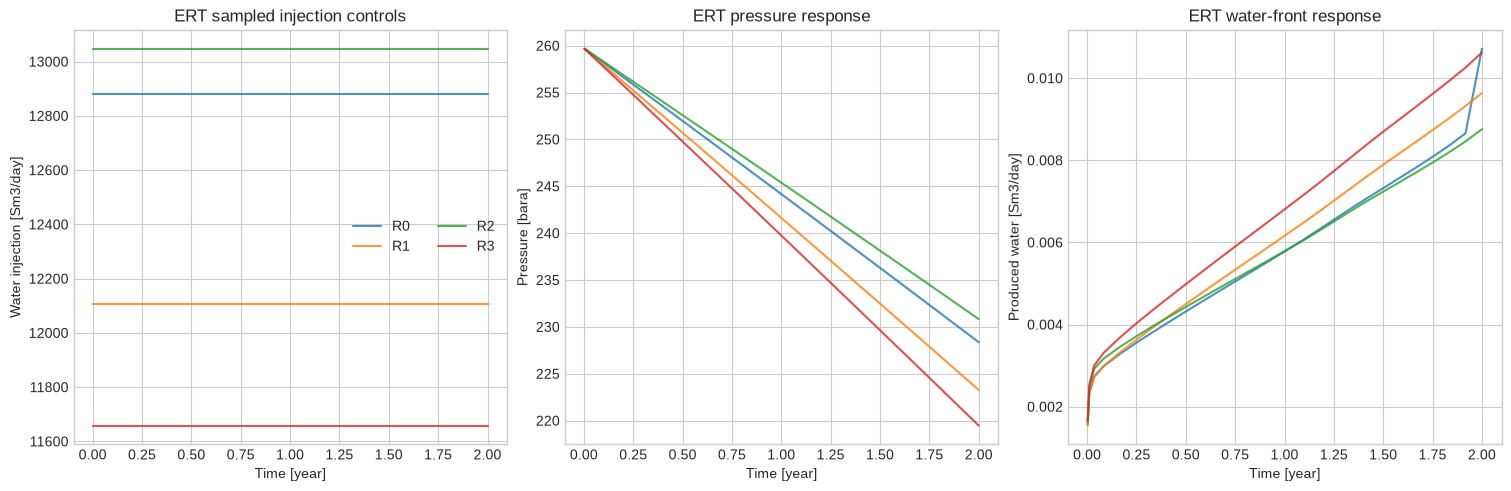

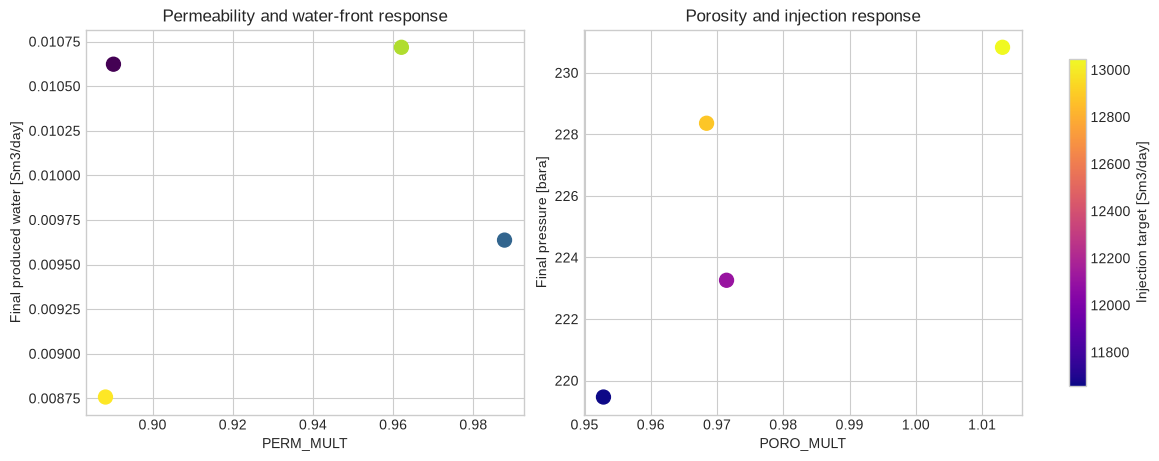

In [34]:
ensemble_frames = []
parameter_rows = []
for realization in range(4):
    run_directory = ERT_DIRECTORY / "runs" / f"realization-{realization}" / "iter-0"
    parameter_payload = json.loads((run_directory / "parameters.json").read_text(encoding="utf-8"))
    parameter_rows.append({
        "realization": realization,
        **{name: float(payload["value"]) for name, payload in parameter_payload.items()},
    })
    realization_summary = ESmry(str(run_directory / "RMS_REEK.SMSPEC"))
    def values(key):
        return np.asarray(realization_summary[key], dtype=float)
    frame = pd.DataFrame({
        "realization": realization,
        "time_days": values("TIME"),
        "field_pressure_bara": values("FPR"),
        "oil_rate_Sm3_day": values("FOPR"),
        "gas_rate_Sm3_day": values("FGPR"),
        "water_rate_Sm3_day": values("FWPR"),
        "water_injection_Sm3_day": values("FWIR"),
        "cumulative_oil_MSm3": values("FOPT") / 1e6,
        "producer_bhp_bara": values("WBHP:PROD"),
        "well_gor_Sm3_Sm3": values("WGOR:PROD"),
    })
    ensemble_frames.append(frame)

ensemble_history = pd.concat(ensemble_frames, ignore_index=True)
ensemble_parameters = pd.DataFrame(parameter_rows).sort_values("realization")
display(ensemble_parameters)
display(ensemble_history.groupby("realization").tail(1))

ensemble_figure, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), constrained_layout=True)
for realization, frame in ensemble_history.groupby("realization"):
    years = frame["time_days"] / 365.25
    axes[0].plot(years, frame["water_injection_Sm3_day"], alpha=0.8, label=f"R{realization}")
    axes[1].plot(years, frame["field_pressure_bara"], alpha=0.8)
    axes[2].plot(years, frame["water_rate_Sm3_day"], alpha=0.8)
axes[0].set(xlabel="Time [year]", ylabel="Water injection [Sm3/day]", title="ERT sampled injection controls")
axes[1].set(xlabel="Time [year]", ylabel="Pressure [bara]", title="ERT pressure response")
axes[2].set(xlabel="Time [year]", ylabel="Produced water [Sm3/day]", title="ERT water-front response")
axes[0].legend(ncol=2)
path = OUTPUT_DIRECTORY / "ert_flow_ensemble.png"
ensemble_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

final_ensemble = ensemble_history.groupby("realization").tail(1).merge(ensemble_parameters, on="realization")
relationship_figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
axes[0].scatter(final_ensemble["PERM_MULT"], final_ensemble["water_rate_Sm3_day"],
                c=final_ensemble["INJ_RATE"], cmap="viridis", s=100)
axes[0].set(xlabel="PERM_MULT", ylabel="Final produced water [Sm3/day]", title="Permeability and water-front response")
scatter = axes[1].scatter(final_ensemble["PORO_MULT"], final_ensemble["field_pressure_bara"],
                          c=final_ensemble["INJ_RATE"], cmap="plasma", s=100)
axes[1].set(xlabel="PORO_MULT", ylabel="Final pressure [bara]", title="Porosity and injection response")
relationship_figure.colorbar(scatter, ax=axes, label="Injection target [Sm3/day]", shrink=0.85)
path = OUTPUT_DIRECTORY / "ert_parameter_response.png"
relationship_figure.savefig(path, dpi=170, bbox_inches="tight")
FIGURE_PATHS.append(path)
plt.show()

## 11. Transfer an ERT realization to NeqSim facilities

The realization closest to median final cumulative oil is selected deterministically. Flow
standard oil, gas, and water rates are reconstructed with the same characterized NeqSim stock
oil and gas phases used to build PVT. The selected maximum-load timestep then feeds a wellhead
choke, three-phase separator, gas compressor, aftercooler, oil letdown valve, and low-pressure
separator. The mass balance is checked.

In [35]:
final_oil = final_ensemble.set_index("realization")["cumulative_oil_MSm3"]
median_target = final_oil.median()
selected_realization = int((final_oil - median_target).abs().idxmin())
reservoir_history = ensemble_history.loc[
    ensemble_history["realization"] == selected_realization
].reset_index(drop=True)
print("Selected median-like realization:", selected_realization)
display(reservoir_history)

Selected median-like realization: 0


,realization,time_days,field_pressure_bara,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,water_injection_Sm3_day,cumulative_oil_MSm3,producer_bhp_bara,well_gor_Sm3_Sm3
0,0,1.0000,259.675354,10000.0,2246727.0,0.001565,12882.124023,0.010000,248.980270,224.672714
1,0,4.0000,259.548553,10000.0,2246727.0,0.002349,12882.124023,0.040000,244.678894,224.672714
2,0,13.0000,259.167816,10000.0,2246727.0,0.002741,12882.124023,0.130000,242.516174,224.672714
3,0,30.4375,258.430298,10000.0,2246727.0,0.002985,12882.124023,0.304375,241.166214,224.672714
4,0,60.8750,257.141663,10000.0,2246727.0,0.003286,12882.124023,0.608750,239.498978,224.672714
5,0,91.3125,255.851395,10000.0,2246727.0,0.003559,12882.124023,0.913125,237.980637,224.672714
6,0,121.7500,254.559509,10000.0,2246727.0,0.003817,12882.124023,1.217500,236.540619,224.672714
7,0,152.1875,253.265930,10000.0,2246727.0,0.004069,12882.124023,1.521875,235.131165,224.672714
8,0,182.6250,251.970718,10000.0,2246727.0,0.004318,12882.124023,1.826250,233.735382,224.672714
9,0,213.0625,250.673798,10000.0,2246727.0,0.004563,12882.124023,2.130625,232.352722,224.672714


In [36]:
stock_oil_template = stock_tank_state.phaseToSystem("oil")
stock_gas_template = stock_tank_state.phaseToSystem("gas")

water_probe = jneqsim.thermo.system.SystemSrkEos(
    STANDARD_TEMPERATURE_C + 273.15,
    STANDARD_PRESSURE_BARA,
)
water_probe.addComponent("water", 1.0)
water_molar_mass_kg_mol = (
    water_probe.getComponent("water").getMolarMass()
)


def reconstruct_characterized_wellhead_fluid(
    oil_rate_sm3_day,
    gas_rate_sm3_day,
    water_rate_sm3_day,
    wellhead_temperature_c=65.0,
    wellhead_pressure_bara=70.0,
):
    stock_oil = stock_oil_template.clone()
    stock_gas = stock_gas_template.clone()
    stock_oil.setTotalFlowRate(float(oil_rate_sm3_day), "m3/day")
    stock_gas.setTotalFlowRate(float(gas_rate_sm3_day), "Sm3/day")

    clearProcess()
    oil_component_stream = stream(
        "Black-oil stock-tank oil component",
        stock_oil,
    )
    gas_component_stream = stream(
        "Black-oil surface-gas component",
        stock_gas,
    )
    recombination_mixer = mixer(
        "Black-oil to characterized-fluid recombination"
    )
    recombination_mixer.addStream(oil_component_stream)
    recombination_mixer.addStream(gas_component_stream)
    runProcess()

    reconstructed_fluid = (
        recombination_mixer.getOutletStream().getFluid().clone()
    )
    hydrocarbon_mass_flow_kg_s = (
        reconstructed_fluid.getFlowRate("kg/sec")
    )
    water_mass_flow_kg_s = (
        float(water_rate_sm3_day)
        * stock_water_density_kg_m3
        / SECONDS_PER_DAY
    )
    water_molar_flow_mol_s = (
        water_mass_flow_kg_s / water_molar_mass_kg_mol
    )

    reconstructed_fluid.addComponent(
        "water",
        water_molar_flow_mol_s,
    )
    reconstructed_fluid.setMixingRule("classic")
    reconstructed_fluid.setMultiPhaseCheck(True)
    reconstructed_fluid.setTemperature(
        wellhead_temperature_c,
        "C",
    )
    reconstructed_fluid.setPressure(
        wellhead_pressure_bara,
        "bara",
    )
    TPflash(reconstructed_fluid)
    reconstructed_fluid.initPhysicalProperties()

    expected_mass_flow_kg_s = (
        hydrocarbon_mass_flow_kg_s + water_mass_flow_kg_s
    )
    audit = {
        "expected_mass_flow_kg_s": expected_mass_flow_kg_s,
        "calculated_mass_flow_kg_s": (
            reconstructed_fluid.getFlowRate("kg/sec")
        ),
        "mass_residual_kg_s": (
            reconstructed_fluid.getFlowRate("kg/sec")
            - expected_mass_flow_kg_s
        ),
    }
    return reconstructed_fluid, audit

In [37]:
reservoir_history["estimated_surface_mass_kg_s"] = (
    reservoir_history["oil_rate_Sm3_day"] * stock_oil_density_kg_m3
    + reservoir_history["gas_rate_Sm3_day"] * stock_gas_density_kg_m3
    + reservoir_history["water_rate_Sm3_day"]
    * stock_water_density_kg_m3
) / SECONDS_PER_DAY

facility_design_index = int(
    reservoir_history["estimated_surface_mass_kg_s"].idxmax()
)
facility_design_row = reservoir_history.iloc[facility_design_index]
facility_feed_fluid, facility_feed_audit = (
    reconstruct_characterized_wellhead_fluid(
        facility_design_row["oil_rate_Sm3_day"],
        facility_design_row["gas_rate_Sm3_day"],
        facility_design_row["water_rate_Sm3_day"],
    )
)

clearProcess()
reservoir_export_stream = stream(
    "OPM-derived characterized wellhead stream",
    facility_feed_fluid,
)
wellhead_choke = valve(
    "Wellhead choke",
    reservoir_export_stream,
    p=55.0,
)
hp_separator = separator3phase(
    "HP three-phase separator",
    wellhead_choke.getOutletStream(),
)
gas_compressor = compressor(
    "Export gas compressor",
    hp_separator.getGasOutStream(),
    pres=120.0,
)
gas_compressor.setIsentropicEfficiency(0.75)
gas_aftercooler = cooler(
    "Export gas aftercooler",
    gas_compressor.getOutletStream(),
)
gas_aftercooler.setOutTemperature(35.0 + 273.15)
oil_valve = valve(
    "Oil letdown valve",
    hp_separator.getOilOutStream(),
    p=10.0,
)
lp_separator = separator(
    "LP oil separator",
    oil_valve.getOutletStream(),
)
runProcess()

In [38]:
process_streams = [
    reservoir_export_stream,
    wellhead_choke.getOutletStream(),
    hp_separator.getGasOutStream(),
    hp_separator.getOilOutStream(),
    hp_separator.getWaterOutStream(),
    gas_aftercooler.getOutletStream(),
    lp_separator.getGasOutStream(),
    lp_separator.getLiquidOutStream(),
]

process_stream_table = pd.DataFrame(
    [
        {
            "stream": str(process_stream.getName()),
            "mass_flow_kg_s": process_stream.getFlowRate("kg/sec"),
            "temperature_C": process_stream.getTemperature("C"),
            "pressure_bara": process_stream.getPressure("bara"),
            "phase_count": (
                process_stream.getFluid().getNumberOfPhases()
            ),
        }
        for process_stream in process_streams
    ]
)

process_outlet_streams = [
    gas_aftercooler.getOutletStream(),
    lp_separator.getGasOutStream(),
    lp_separator.getLiquidOutStream(),
    hp_separator.getWaterOutStream(),
]
process_outlet_mass_flow_kg_s = sum(
    process_stream.getFlowRate("kg/sec")
    for process_stream in process_outlet_streams
)
process_mass_residual_kg_s = (
    reservoir_export_stream.getFlowRate("kg/sec")
    - process_outlet_mass_flow_kg_s
)

process_performance = pd.DataFrame(
    {
        "quantity": [
            "Flow forecast time",
            "Flow oil rate",
            "Flow gas rate",
            "Flow water rate",
            "NeqSim feed mass rate",
            "process mass residual",
            "compressor power",
            "aftercooler duty",
        ],
        "value": [
            facility_design_row["time_days"] / 365.25,
            facility_design_row["oil_rate_Sm3_day"],
            facility_design_row["gas_rate_Sm3_day"],
            facility_design_row["water_rate_Sm3_day"],
            reservoir_export_stream.getFlowRate("kg/sec"),
            process_mass_residual_kg_s,
            gas_compressor.getPower() / 1.0e6,
            gas_aftercooler.getDuty() / 1.0e6,
        ],
        "unit": [
            "year",
            "Sm³/day",
            "Sm³/day",
            "Sm³/day",
            "kg/s",
            "kg/s",
            "MW",
            "MW",
        ],
    }
)

display(process_stream_table)
display(process_performance)

,stream,mass_flow_kg_s,temperature_C,pressure_bara,phase_count
0,OPM-derived characterized wellhead stream,3.044458e+01,65.000000,70.0,2
1,Wellhead choke out stream,3.044458e+01,58.917887,55.0,2
2,gasOutStream,2.572056e+01,58.917887,55.0,1
3,liquidOutStream,4.724020e+00,58.917887,55.0,1
4,waterOutStream,5.507958e-29,58.917887,55.0,2
5,outStream,2.572056e+01,35.000000,120.0,1
6,gasOutStream,8.456356e-01,38.404878,10.0,1
7,liquidOutStream,3.878385e+00,38.404878,10.0,1


,quantity,value,unit
0,Flow forecast time,2.000000e+00,year
1,Flow oil rate,1.000000e+04,Sm³/day
2,Flow gas rate,2.246727e+06,Sm³/day
3,Flow water rate,1.071783e-02,Sm³/day
4,NeqSim feed mass rate,3.044458e+01,kg/s
5,process mass residual,5.423573e-11,kg/s
6,compressor power,2.680346e+00,MW
7,aftercooler duty,-7.344375e+00,MW


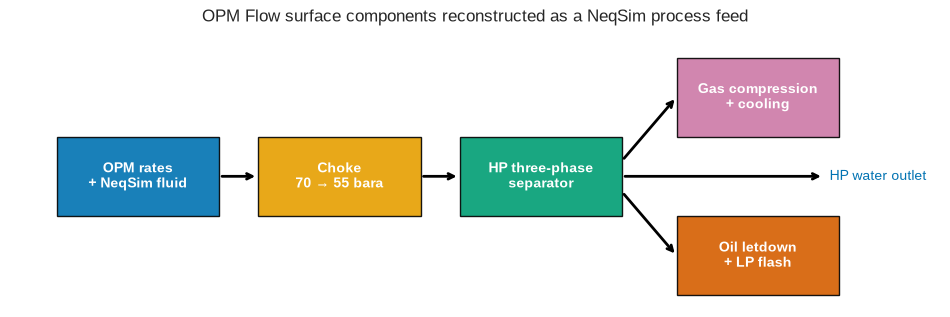

In [39]:
process_figure, process_axis = plt.subplots(figsize=(12.0, 3.6))
process_axis.set_xlim(0.0, 12.0)
process_axis.set_ylim(0.0, 3.5)
process_axis.axis("off")

process_nodes = [
    (0.6, 1.15, "OPM rates\n+ NeqSim fluid", "#0072B2"),
    (3.2, 1.15, "Choke\n70 → 55 bara", "#E69F00"),
    (5.8, 1.15, "HP three-phase\nseparator", "#009E73"),
    (8.6, 2.15, "Gas compression\n+ cooling", "#CC79A7"),
    (8.6, 0.15, "Oil letdown\n+ LP flash", "#D55E00"),
]

for x_position, y_position, label, color in process_nodes:
    process_axis.add_patch(
        plt.Rectangle(
            (x_position, y_position),
            2.1,
            1.0,
            facecolor=color,
            edgecolor="black",
            alpha=0.9,
        )
    )
    process_axis.text(
        x_position + 1.05,
        y_position + 0.5,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

arrow_pairs = [
    ((2.7, 1.65), (3.2, 1.65)),
    ((5.3, 1.65), (5.8, 1.65)),
    ((7.9, 1.85), (8.6, 2.65)),
    ((7.9, 1.45), (8.6, 0.65)),
    ((7.9, 1.65), (10.5, 1.65)),
]
for arrow_start, arrow_end in arrow_pairs:
    process_axis.annotate(
        "",
        xy=arrow_end,
        xytext=arrow_start,
        arrowprops={"arrowstyle": "->", "linewidth": 2.0},
    )

process_axis.text(
    11.2,
    1.65,
    "HP water outlet",
    ha="center",
    va="center",
    color="#0072B2",
)
process_axis.set_title(
    "OPM Flow surface components reconstructed as a NeqSim process feed"
)

process_plot_path = OUTPUT_DIRECTORY / "integrated_process_workflow.png"
process_figure.savefig(process_plot_path, dpi=150)
plt.show()
FIGURE_PATHS.append(process_plot_path)

## 12. Complete input and artifact inventory

The tables below list every downloaded input and every generated simulator input with byte count
and SHA-256. The complete deck, PVT include, relative-permeability tables, ERT configuration,
priors, and Jinja template were printed above. Cell-scale arrays remain available through their
immutable ROFF URLs and generated GRDECL files; checksums prove the exact bytes used.

In [40]:
input_artifact_paths = (
    [DATA_DIRECTORY / row[0] for row in DATA_MANIFEST]
    + generated_static_paths
    + [black_oil_path, deck_path, ERT_DIRECTORY / "parameters.txt",
       ERT_DIRECTORY / "RMS_REEK.DATA.jinja2", ert_config_path, job_path]
)
input_inventory = pd.DataFrame([
    {
        "role": "downloaded public input" if path.parent == DATA_DIRECTORY else "generated simulation input",
        "file": path.relative_to(OUTPUT_DIRECTORY).as_posix(),
        "bytes": path.stat().st_size,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
    }
    for path in input_artifact_paths
])
display(input_inventory)

ledger_path = OUTPUT_DIRECTORY / "agent_tool_ledger.json"
ledger_path.write_text(json.dumps(agent_ledger.records, indent=2) + "\n", encoding="utf-8")
display(agent_ledger.frame())

,role,file,bytes,sha256
0,downloaded public input,input/0readme.txt,149,8f76ce966e77a13cdeb1be9bf021b330719f34ac51d810...
1,downloaded public input,input/reek_geo2_grid_3props.roff,7837496,cf199d7126dc96b574e05c6709a5216f454e2da7ff5e01...
2,downloaded public input,input/reek_sim_grid.roff,376580,6454b7aa1d1f2701438310b8b3dc3101e70dd9643b49ec...
3,downloaded public input,input/reek_sim_poro.roff,143718,7368cc75d0436c3816fd16d61f77621c00f4f97ec25f0f...
4,downloaded public input,input/reek_sim_permx.roff,143719,37866e0fb8d9ab8e036f2ed9d34537a7274efbf6346652...
5,downloaded public input,input/reek_sim_facies2.roff,143786,6aeb52f6dd41f1e0783fb998a92b3da08cfa0f8fd5621f...
6,downloaded public input,input/reek_sim_zone.roff,143825,1d8f60577a4da72b6234eb036e8d1d0248513fb93d61b9...
7,generated simulation input,REEK_GRID.GRDECL,5576400,f52cc87ee49ae0f715e504910386c67593be7a301d36e8...
8,generated simulation input,PORO.GRDECL,471901,bd6e51ace0e867d61c4f72504109bb679e2dfc5124454e...
9,generated simulation input,PERMX.GRDECL,471902,885fb2e50c8de23b22efff0b5d27f356bb25a736de2b5f...


,sequence,tool,status,evidence
0,1,rms.inspect_project,fixture_passed,{'data_commit': 'cad17f24e22c19c6cefe6f6471853...
1,2,rms.run_workflow,fixture_passed,"{'workflow': 'REEK_BLOCK_AND_EXPORT_V1', 'bloc..."
2,3,rms.export_grid,fixture_passed,{'grid_sha256': 'f52cc87ee49ae0f715e504910386c...
3,4,neqsim.generate_pvt,passed,{'source_commit': '1f7a01b06307d9d56451e43bb8d...
4,5,opm.validate,passed,{'keywords': 17}
5,6,opm.run,passed,"{'return_code': 0, 'restart_steps': 25}"
6,7,ert.ensemble_experiment,passed,"{'return_code': 0, 'wall_time_seconds': 39.124..."


## 13. Engineering validation gates

These assertions are publication gates, not decorative status labels. They check provenance,
dimensions, blocking, property physics, deck parsing, the real Flow process, restart saturation
closure, all four ERT simulator runs, NeqSim PVT contracts, the process mass balance, and the
agent ledger. A failed check raises and leaves the notebook unpublishable.

In [41]:
all_ert_smspec = [
    ERT_DIRECTORY / "runs" / f"realization-{realization}" / "iter-0" / "RMS_REEK.SMSPEC"
    for realization in range(4)
]
saturation_sum = final_water_saturation_cube + final_gas_saturation_cube
validation_checks = {
    "all seven public files match SHA-256 and byte count": bool(download_table["verified"].all()),
    "fine grid is 80 x 128 x 56": (fine_grid.ncol, fine_grid.nrow, fine_grid.nlay) == (80, 128, 56),
    "simulation grid is 40 x 64 x 14": (sim_grid.ncol, sim_grid.nrow, sim_grid.nlay) == (40, 64, 14),
    "fine-to-simulation blocking is exactly 2 x 2 x 4": BLOCK == (2, 2, 4),
    "simulation grid has 35,838 active cells": sim_grid.nactive == 35838,
    "porosity remains between zero and one": bool(active_poro.min() > 0 and active_poro.max() < 1),
    "permeability is positive": bool(active_permx.min() > 0),
    "blocked porosity is finite on compared blocks": bool(np.isfinite(blocked_poro[comparison_mask]).all()),
    "all generated static includes are nonempty": all(path.stat().st_size > 0 for path in generated_static_paths),
    "all required Flow deck keywords parse": bool(deck_keyword_audit["present"].all()),
    "all NeqSim PVT contracts pass": bool(pvt_contract_audit["passed"].all()),
    "OPM Flow returned success": flow_run.returncode == 0,
    "Flow summary is finite": bool(np.isfinite(reservoir_history.select_dtypes(include=[np.number])).all().all()),
    "restart active count matches XTGeo": active_cell_count == sim_grid.nactive,
    "restart has 24 forecast steps plus initial state": len(restart_steps) in (24, 25),
    "restart states are finite on active cells": bool(np.isfinite(final_pressure_cube_bara[~np.isnan(final_pressure_cube_bara)]).all()),
    "final saturations close": bool(np.nanmin(final_oil_saturation_cube) >= -1e-6 and np.nanmax(saturation_sum) <= 1 + 1e-6),
    "ERT lint returned success": ert_lint.returncode == 0,
    "ERT ensemble returned success": ert_run.returncode == 0,
    "all four ERT SMSPEC files exist": all(path.is_file() for path in all_ert_smspec),
    "ERT parsed four realizations": ensemble_history["realization"].nunique() == 4,
    "NeqSim process compressor consumes power": gas_compressor.getPower() > 0,
    "NeqSim process mass balance closes": abs(process_mass_residual_kg_s) < 1e-8,
    "at least eleven retained figures exist": len(list(OUTPUT_DIRECTORY.glob("*.png"))) >= 11,
    "agent ledger records all executed stages as passed": all(record["status"].endswith("passed") for record in agent_ledger.records),
    "job contract contains no filesystem project path": "project_path" not in json.dumps(agent_job),
}
validation_table = pd.DataFrame({"check": validation_checks.keys(), "passed": validation_checks.values()})
display(validation_table)
failed = validation_table.loc[~validation_table["passed"], "check"].tolist()
if failed:
    raise AssertionError(f"Failed validation checks: {failed}")
print(f"All {len(validation_checks)} engineering validation gates passed.")

,check,passed
0,all seven public files match SHA-256 and byte ...,True
1,fine grid is 80 x 128 x 56,True
2,simulation grid is 40 x 64 x 14,True
3,fine-to-simulation blocking is exactly 2 x 2 x 4,True
4,"simulation grid has 35,838 active cells",True
5,porosity remains between zero and one,True
6,permeability is positive,True
7,blocked porosity is finite on compared blocks,True
8,all generated static includes are nonempty,True
9,all required Flow deck keywords parse,True


All 26 engineering validation gates passed.


In [42]:
final_results = {
    "data_commit": DATA_COMMIT,
    "neqsim_commit": neqsim_commit,
    "neqsim_jar_sha256": neqsim_jar_sha256,
    "grid_dimensions": [grid_nx, grid_ny, grid_nz],
    "active_cells": active_cell_count,
    "blocking": list(BLOCK),
    "porosity_blocking_rmse": float(np.sqrt(np.mean(poro_difference ** 2))),
    "bubble_pressure_bara": float(bubble_pressure_bara),
    "base_final_pressure_bara": float(summary_values("FPR")[-1]),
    "base_final_cumulative_oil_million_sm3": float(summary_values("FOPT")[-1] / 1e6),
    "ert_realizations": int(ensemble_history["realization"].nunique()),
    "ert_final_oil_range_million_sm3": [
        float(final_ensemble["cumulative_oil_MSm3"].min()),
        float(final_ensemble["cumulative_oil_MSm3"].max()),
    ],
    "ert_final_pressure_range_bara": [
        float(final_ensemble["field_pressure_bara"].min()),
        float(final_ensemble["field_pressure_bara"].max()),
    ],
    "ert_final_water_rate_range_sm3_day": [
        float(final_ensemble["water_rate_Sm3_day"].min()),
        float(final_ensemble["water_rate_Sm3_day"].max()),
    ],
    "selected_process_realization": selected_realization,
    "compressor_power_MW": float(gas_compressor.getPower() / 1e6),
    "process_mass_residual_kg_s": float(process_mass_residual_kg_s),
    "figures": [path.name for path in FIGURE_PATHS],
    "validation_checks_passed": int(validation_table["passed"].sum()),
    "validation_checks_total": len(validation_table),
}
results_path = OUTPUT_DIRECTORY / "run_results.json"
results_path.write_text(json.dumps(final_results, indent=2) + "\n", encoding="utf-8")
display(pd.DataFrame([
    ("Active cells", active_cell_count, "count"),
    ("NeqSim bubble pressure", bubble_pressure_bara, "bara"),
    ("Base final pressure", final_results["base_final_pressure_bara"], "bara"),
    ("Base cumulative oil", final_results["base_final_cumulative_oil_million_sm3"], "million Sm3"),
    ("ERT minimum final pressure", final_results["ert_final_pressure_range_bara"][0], "bara"),
    ("ERT maximum final pressure", final_results["ert_final_pressure_range_bara"][1], "bara"),
    ("ERT minimum final water rate", final_results["ert_final_water_rate_range_sm3_day"][0], "Sm3/day"),
    ("ERT maximum final water rate", final_results["ert_final_water_rate_range_sm3_day"][1], "Sm3/day"),
    ("Selected compressor power", final_results["compressor_power_MW"], "MW"),
], columns=["result", "value", "unit"]).round(6))
print(json.dumps(final_results, indent=2))

,result,value,unit
0,Active cells,35838.000000,count
1,NeqSim bubble pressure,193.240400,bara
2,Base final pressure,223.618027,bara
3,Base cumulative oil,7.305000,million Sm3
4,ERT minimum final pressure,219.467545,bara
5,ERT maximum final pressure,230.828323,bara
6,ERT minimum final water rate,0.008757,Sm3/day
7,ERT maximum final water rate,0.010718,Sm3/day
8,Selected compressor power,2.680346,MW


{
  "data_commit": "cad17f24e22c19c6cefe6f647185395cc0a11add",
  "neqsim_commit": "1f7a01b06307d9d56451e43bb8d6023d28d14007",
  "neqsim_jar_sha256": "39e1de9738baaef18726c5d7a3f9cccf3a8af29a8e39761f90d92b870b0a857a",
  "grid_dimensions": [
    40,
    64,
    14
  ],
  "active_cells": 35838,
  "blocking": [
    2,
    2,
    4
  ],
  "porosity_blocking_rmse": 0.0918770723782011,
  "bubble_pressure_bara": 193.24040031433105,
  "base_final_pressure_bara": 223.61802673339844,
  "base_final_cumulative_oil_million_sm3": 7.305,
  "ert_realizations": 4,
  "ert_final_oil_range_million_sm3": [
    7.305,
    7.305
  ],
  "ert_final_pressure_range_bara": [
    219.46754455566406,
    230.8283233642578
  ],
  "ert_final_water_rate_range_sm3_day": [
    0.008757241070270538,
    0.010717831552028656
  ],
  "selected_process_realization": 0,
  "compressor_power_MW": 2.680346000234267,
  "process_mass_residual_kg_s": 5.423572702056845e-11,
  "figures": [
    "workflow_architecture.png",
    "reek_st

## What is demonstrated, and what is not

**Demonstrated with stored execution evidence**

- public RMS-origin ROFF ingestion;
- geological-to-simulation blocking calculations;
- RMS-export property inspection and spatial spreading;
- NeqSim master-source PVT generation;
- complete OPM Flow deck generation and dynamic simulation;
- restart-state visualization;
- real ERT orchestration of four OPM Flow realizations;
- reservoir-to-NeqSim facility handover;
- machine-readable agent request, allow-list, acceptance checks, and tool ledger.

**Not claimed**

- The public Reek export is not a confidential asset model.
- The explicit teaching facies map is not asserted to be the archived RMS workflow definition.
- PERMY and PERMZ multipliers are assumptions, not measurements.
- The wells and controls are visualization choices, not an optimized development plan.
- Four ERT realizations demonstrate integration; they do not quantify decision-grade uncertainty.
- The notebook does not execute licensed RMS. That execution belongs on a governed worker.
- PVT, rock-fluid functions, contacts, and controls are illustrative and are not history matched.

A production implementation should add RMS project snapshots, signed artifacts, scheduler/resource
limits, secret-free workload identity, approval gates, observation ingestion, ERT update steps,
and domain review before model promotion.

## Suggested exercises

1. Replace the supplied simulation PORO with the calculated blocked porosity and compare Flow.
2. Implement harmonic, arithmetic, and flow-based directional permeability upscaling.
3. Add region-specific SWOF/SGOF tables using facies or Zone.
4. Increase the ERT ensemble and add observed well data for an ensemble smoother experiment.
5. Add fault transmissibility multipliers and inspect water-front sensitivity.
6. Replace the public-fixture adapter with an authenticated licensed RMS worker in a test project.
7. Extend the agent contract with artifact signatures, approvals, and a model-promotion state machine.

## References

- NeqSim: https://github.com/equinor/neqsim
- NeqSim-Colab: https://github.com/EvenSol/NeqSim-Colab
- OPM Flow: https://opm-project.org
- ERT: https://ert.readthedocs.io
- XTGeo: https://xtgeo.readthedocs.io
- Public test data: https://github.com/equinor/xtgeo-testdata
- Reek source commit: cad17f24e22c19c6cefe6f647185395cc0a11add